In [130]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Definitions

In [4]:
import matplotlib.pyplot as plt

import numpy as np
from scipy.sparse.linalg import expm_multiply
from scipy.special import gamma
from simulation import System, Eletric_field, Leg

from simulation import add_atom_to_hamiltonian, time_evolution_lattice, time_evolution_atom
from lattice import Graphene

In [5]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Avenir', 'DejaVu Sans', 'Lucida Grande', 'Verdana']
plt.rcParams['font.size'] = 16
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 16  # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 16  


PATH = "./plots/"

In [6]:
def slice_graphene(na, nb, Cna, Cnb, x_slice=0.0, tol=0.5):
    mask_a = np.abs(na[0] - x_slice) < tol
    mask_b = np.abs(nb[0] - x_slice) < tol

    # Handle 1D (single eigenvector), 2D (NMAX x NMAX), or 3D (T x NMAX x NMAX)
    single = Cna.ndim <= 2
    if Cna.ndim == 1:
        # Already flat: (N_atoms,) → (1, N_atoms)
        cna_flat = Cna[np.newaxis]
        cnb_flat = Cnb[np.newaxis]
    else:
        if Cna.ndim == 2:
            Cna = Cna[np.newaxis]  # (1, NMAX, NMAX)
            Cnb = Cnb[np.newaxis]
        # Flatten spatial dims: (T, NMAX*NMAX)
        cna_flat = Cna.reshape(Cna.shape[0], -1)
        cnb_flat = Cnb.reshape(Cnb.shape[0], -1)

    sort_a = np.argsort(na[1][mask_a])
    sort_b = np.argsort(nb[1][mask_b])

    y_a = na[1][mask_a][sort_a]
    y_b = nb[1][mask_b][sort_b]
    c_a = cna_flat[:, mask_a][:, sort_a]
    c_b = cnb_flat[:, mask_b][:, sort_b]

    if single:
        return (y_a, c_a[0]), (y_b, c_b[0])
    
    return (y_a, c_a), (y_b, c_b)

def find_two_maxima(y, c_t):
    """
    Given density profile c_t at a single timestep, return the y-positions
    of the two largest maxima.
    """
    idx = np.argsort(c_t)[-2:]       # indices of 2 largest values
    idx = idx[np.argsort(y[idx])]    # sort by y so left peak is first
    return y[idx]                    # shape (2,)


def track_maxima_over_time(y, c_all):
    """
    c_all: (NUM_POINTS, N_slice_atoms)
    Returns positions array of shape (NUM_POINTS, 2),
    where [:, 0] is left peak and [:, 1] is right peak.
    """
    return np.array([find_two_maxima(y, c_all[t]) for t in range(len(c_all))])

def plot_graphene(na, nb, Cna, Cnb, ax, s=5, cmap="hot", vmin=None, vmax=None, logscale=None, rasterize=True):
    if logscale:
        Cna = np.log10(Cna)
        Cnb = np.log10(Cnb)

    im = ax.scatter(na[0], na[1] ,c=Cna, s=s, label="A", cmap=cmap, vmin=vmin, vmax=vmax, rasterized=rasterize)
    ax.scatter(nb[0], nb[1], c=Cnb, s=s, label="B", cmap=cmap, vmin=vmin, vmax=vmax,rasterized=rasterize)

    return im

# Structure of the lattice

In [7]:
NMAX = 40

# print(connections[0])
lattice=Graphene(nmax=NMAX, pbc=None)

a1 = lattice.a1
a2 = lattice.a2
d1 = lattice.d1

na, nb = lattice.n_real_pos

In [ ]:
def compute_positions_along_line(lattice):
  """
    Computes real lattice positions for sites that lie n a line at y = 0. The
    positions that fullfil such a thing are giving by

    $R_a = n a_1 + m a_2$, such that $n = -2m$
    $R_b = n a_1 + m a_2 + \delta$, such that $n =1 -2m$
  """
  NMAX = lattice.nmax
  a1 = lattice.a1
  a2 = lattice.a2
  d1 = lattice.d1

  m = np.arange(-(NMAX//2), NMAX//2)

  na_line = []
  nb_line = []

  for mm in m:
    n = - 2 * mm
    if n in m:
      ra = n * a1 + mm * a2
      na_line.append(ra)
  
    n = 1 - 2 * mm
    if n in m:
      rb = n * a1 + mm * a2 + d1
      nb_line.append(rb)

  return np.array(na_line).T, np.array(nb_line).T


def compute_positions_along_direction_a1(lattice):
  NMAX = lattice.nmax
  a1 = lattice.a1
  a2 = lattice.a2
  d1 = lattice.d1

  m = np.arange(-(NMAX//2), NMAX//2)
  
  na_line = []
  nb_line = []

  n = 0.
  for mm in m:
    ra = mm * a1

    na_line.append(ra)

    rb = mm * a1 + d1
    nb_line.append(rb)

  return np.array(na_line).T, np.array(nb_line).T


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/var/folders/q3/1z3g104x46n7562_5r_mvpl80000gn/T/ipykernel_99044/367910092.py:2: SyntaxWarning: invalid escape sequence '\d'
  """


In [12]:
lattice.a1, lattice.a2

(array([1.5      , 0.8660254]), array([0.        , 1.73205081]))

In [ ]:
# na_line, nb_line = compute_positions_along_line(lattice)
na_line, nb_line = compute_positions_along_direction_a1(lattice)

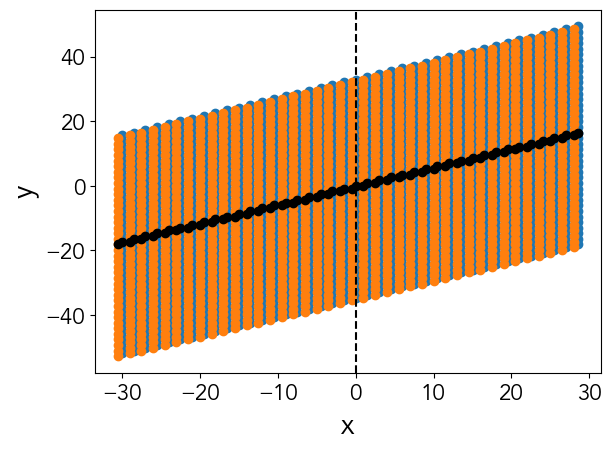

In [27]:
plt.scatter(na[0], na[1])
plt.scatter(nb[0], nb[1])

plt.scatter(na_line[0], na_line[1], color="black")
plt.scatter(nb_line[0], nb_line[1], color="black")


w = 10
x0 = 0.
# plt.xlim(-w, w)
# plt.ylim(-w, w)
# 
# plt.xlim(20, 30)
# # plt.xlim(-31, -20)
# plt.ylim(-10, 10)
plt.axvline(x0, color="black", linestyle="dashed")

plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
# plt.savefig(PATH + "domain_wall_lattice.pdf", bbox_inches="tight")

In [26]:
NMAX

40

In [28]:
na_line.shape

(2, 40)

In [29]:
na_line[0]

array([-30. , -28.5, -27. , -25.5, -24. , -22.5, -21. , -19.5, -18. ,
       -16.5, -15. , -13.5, -12. , -10.5,  -9. ,  -7.5,  -6. ,  -4.5,
        -3. ,  -1.5,   0. ,   1.5,   3. ,   4.5,   6. ,   7.5,   9. ,
        10.5,  12. ,  13.5,  15. ,  16.5,  18. ,  19.5,  21. ,  22.5,
        24. ,  25.5,  27. ,  28.5])

In [30]:
nb_line[0]

array([-30.5, -29. , -27.5, -26. , -24.5, -23. , -21.5, -20. , -18.5,
       -17. , -15.5, -14. , -12.5, -11. ,  -9.5,  -8. ,  -6.5,  -5. ,
        -3.5,  -2. ,  -0.5,   1. ,   2.5,   4. ,   5.5,   7. ,   8.5,
        10. ,  11.5,  13. ,  14.5,  16. ,  17.5,  19. ,  20.5,  22. ,
        23.5,  25. ,  26.5,  28. ])

<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
/var/folders/q3/1z3g104x46n7562_5r_mvpl80000gn/T/ipykernel_40886/461631597.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta(x)$")


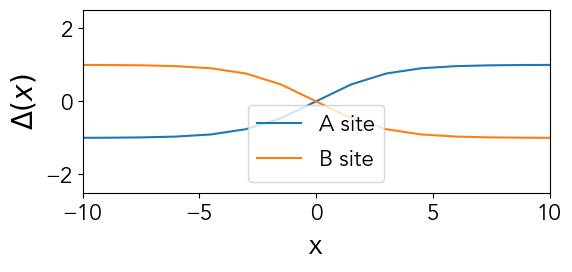

In [138]:
l = 3
x0 = 0



delta = np.tanh((na[0] - x0)/l)
idx = np.argsort(delta)

plt.figure(figsize=(6,3))

plt.xlim(-w, w)
plt.ylim(-2.5, 2.5)


plt.plot(na[0,idx ], delta[idx], label="A site")
plt.plot(na[0,idx ], -delta[idx], label="B site")

plt.xlabel("x")
plt.ylabel("$\Delta(x)$")

plt.legend()

plt.tight_layout()
plt.savefig(PATH + "domain_wall_lattice_mass_profile.pdf", bbox_inches="tight")

Text(0, 0.5, 'Eigenvalues')

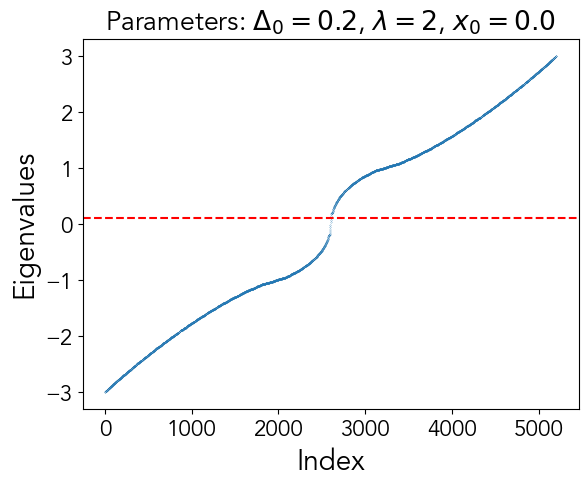

In [143]:
nmax = 51
delta = 0.2
lambda_0 = 2
x0 = 0.

lattice = Graphene(nmax=nmax, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=0)


eigval, eigvec = np.linalg.eigh(lattice.hamiltonian.todense())

plt.plot(eigval, "o", markersize=0.1)

plt.axhline(0.1, color="red", linestyle="dashed")
plt.title(f"Parameters: $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$, $x_0 = {x0}$")
plt.xlabel("Index")
plt.ylabel("Eigenvalues")

# Visualizing the gap state

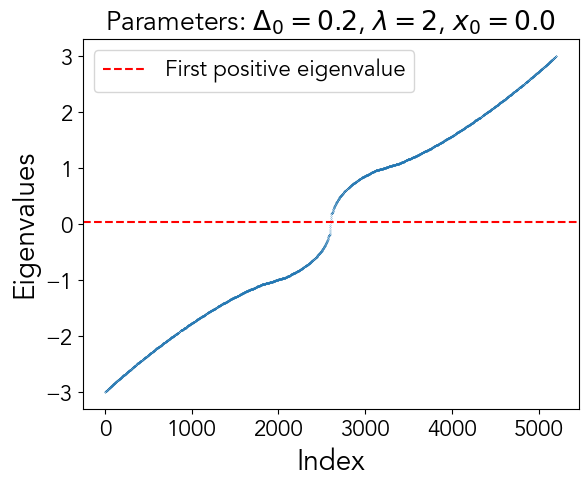

In [144]:
plt.plot(eigval, "o", markersize=0.1)
idx = np.where(eigval > 0)[0][0] # get the first positive

plt.axhline(eigval[idx], color="red", linestyle="dashed", label="First positive eigenvalue")
plt.title(f"Parameters: $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$, $x_0 = {x0}$")
plt.xlabel("Index")
plt.ylabel("Eigenvalues")

plt.legend()

Text(0.5, 0, 'x')

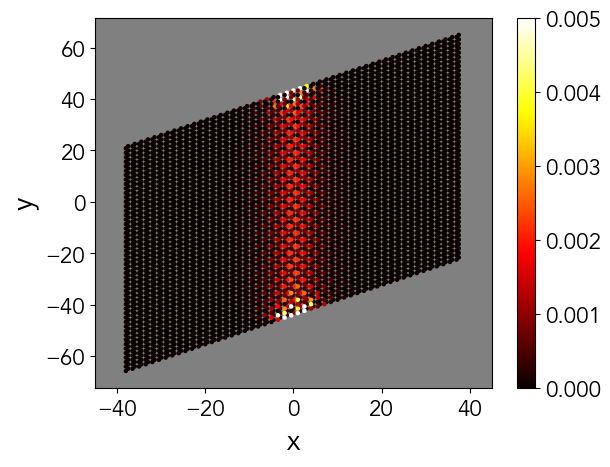

In [148]:
idx = np.where(eigval > 0)[0][0] # get the first positive
psi = np.asarray(eigvec[:, idx-1]).flatten()

psi_a = psi[:lattice.la]
psi_b = psi[lattice.la:]

na, nb = lattice.n_real_pos
Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2


fig, ax = plt.subplots()

im = plot_graphene(na, nb, Cna, Cnb, ax, vmax = 0.005)
plt.colorbar(im)

# ax.set_aspect("equal")
ax.set_xlim(-45, 45)

ax.set_facecolor("gray")

ax.set_ylabel("y")
ax.set_xlabel("x")

In [232]:
(ya, ca), (yb, cb) = slice_graphene(na, nb, Cna = Cna, Cnb = Cnb)

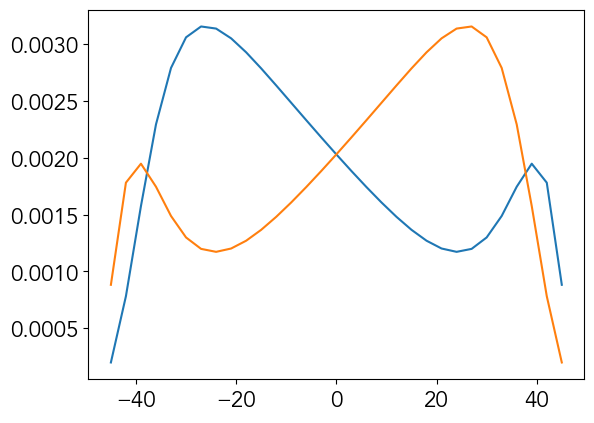

In [234]:
plt.plot(ya, ca)
plt.plot(ya, cb)

# Group velocity

In [23]:
NMAX = 251
delta = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.014
G = 0.1
atom_pos = (0,0)
NUM_POINTS = 25
TF = 200

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=0)

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2



## Checking emission for a normal atom

In [17]:
NMAX = 251
delta = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.014
G = 0.1
atom_pos = (0,0)
NUM_POINTS = 25
TF = 200

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=0)

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2



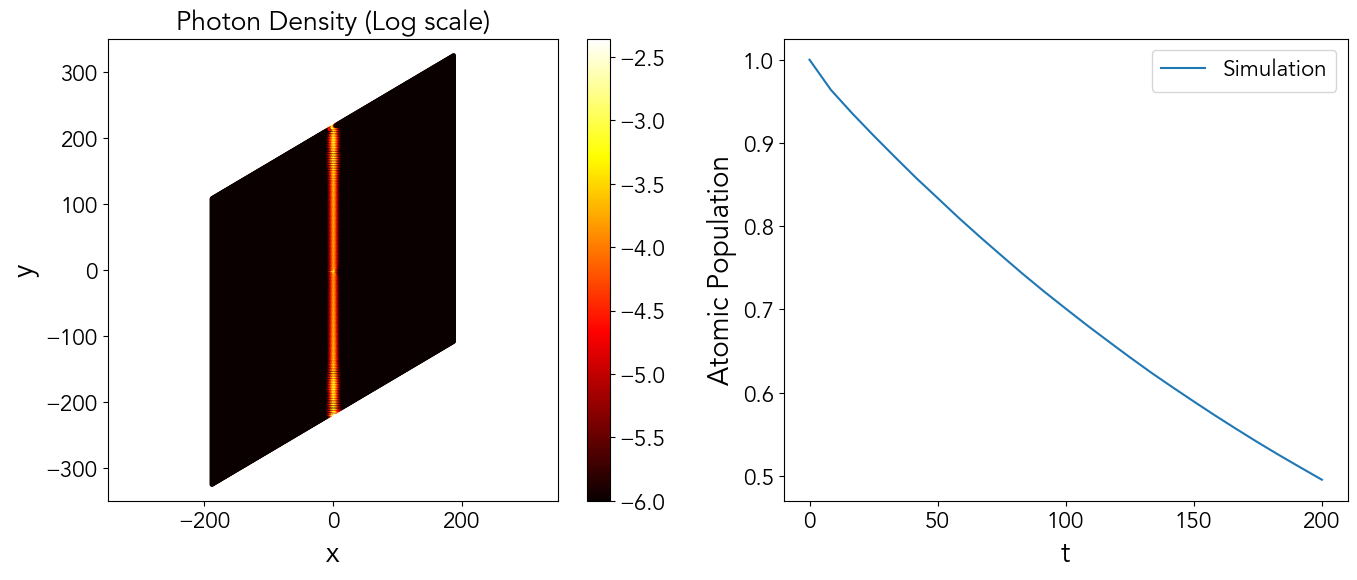

In [ ]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe, label="Simulation")
axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\delta/2 = {DELTA/2}$")

axs[0].set_ylim(-350,350)
axs[0].set_xlim(-350, 350)

axs[1].legend()
plt.show()

fig.tight_layout()
fig.savefig(PATH + "emission_normal_atom.pdf", bbox_inches="tight")


ValueError: x and y must have same first dimension, but have shapes (31,) and (1,)

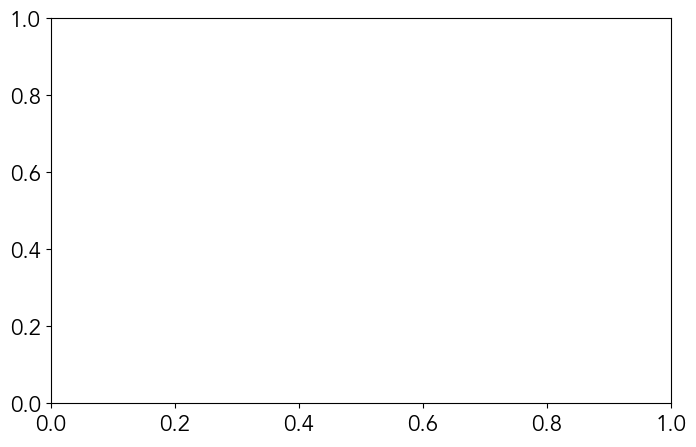

In [31]:
(y_a, c_a), (y_b, c_b) = slice_graphene(na, nb, Cna, Cnb)
fig, ax = plt.subplots(figsize=(8, 5))

t_indx = [10,12]

ax.plot(y_a, c_a[t_indx[0]], label=f"t = {t[t_indx[0]]:.2f}")
ax.plot(y_a, c_a[t_indx[1]], label=f"t = {t[t_indx[1]]:.2f}")

ax.set_ylabel("Photon Density")

ax.set_xlabel("y")
ax.legend()
plt.tight_layout()

ax.set_title("Sublattice A")
# plt.xlim(-100, 100)
plt.show()

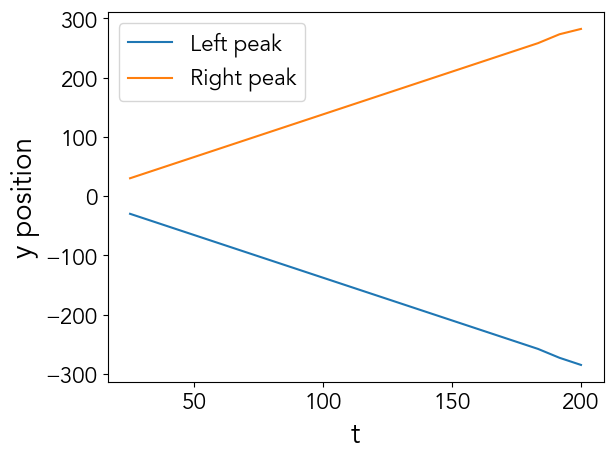

In [155]:
(y_a, c_a), _ = slice_graphene(na, nb, Cna, Cnb, x_slice=0.0)

positions = track_maxima_over_time(y_a, c_a)  # (NUM_POINTS, 2)

start = 3
plt.plot(t[start:], positions[start:, 0], label="Left peak")
plt.plot(t[start:], positions[start:, 1], label="Right peak")
plt.xlabel("t")
plt.ylabel("y position")
plt.legend()

# plt.xlim(10, 200)

## Checking the decay rate for gapless graphene

In [195]:
NMAX = 451
delta = 0.0
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.15
G = 0.05
atom_pos = (0,0)
NUM_POINTS = 25
TF = 200

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=0)

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2



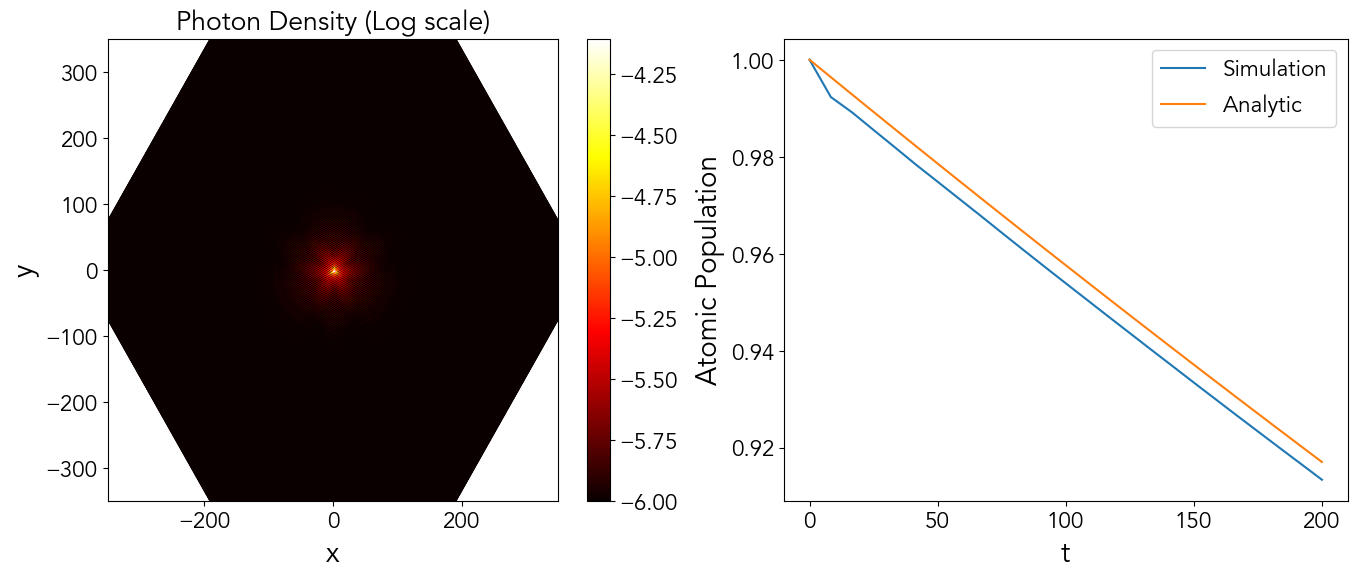

In [203]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe, label="Simulation")


vf = 3/2
beta = 2 * delta * lambda_0/vf
# decay_rate = (G ** 2 ) / (vf * lambda_0 * np.sqrt(np.pi)) * gamma(beta/2 + 1/2) / gamma(beta/2)

decay_rate = G ** 2 * 3 * np.sqrt(3) * OMEGA_0/ (2 * vf ** 2)
pe_analyitic = np.exp(-t * decay_rate)
axs[1].plot(t, pe_analyitic, label="Analytic")

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\delta/2 = {DELTA/2}$")

axs[0].set_ylim(-350,350)
axs[0].set_xlim(-350, 350)

axs[1].legend()
plt.show()

fig.tight_layout()
fig.savefig(PATH + "emission_normal_atom.pdf", bbox_inches="tight")


a = 0.9962 ± 0.0000
b = 0.0004 ± 0.0000


/var/folders/q3/1z3g104x46n7562_5r_mvpl80000gn/T/ipykernel_5946/4162860962.py:5: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)


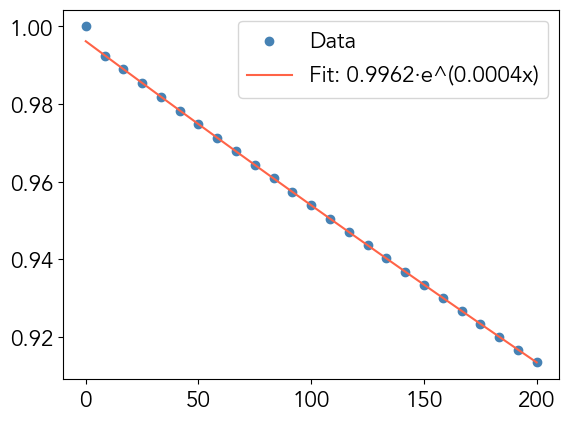

In [205]:
from scipy.optimize import curve_fit

# Define the model: y = a * e^(b*x)
def exponential(x, a, b):
    return a * np.exp(-b * x)

# Fit — p0 is the initial guess for [a, b]
params, covariance = curve_fit(exponential, t[1:], pe[1:], p0=[1, 0.5])
a, b = params

# Uncertainty (1 standard deviation)
std_devs = np.sqrt(np.diag(covariance))
print(f"a = {a:.4f} ± {std_devs[0]:.4f}")
print(f"b = {b:.4f} ± {std_devs[1]:.4f}")

# Plot
# x_fit = np.linspace(x.min(), x.max(), 200)
plt.scatter(t, pe, label="Data", color="steelblue")
plt.plot(t, exponential(t, a, b), label=f"Fit: {a:.4f}·e^({b:.4f}x)", color="tomato")
plt.legend()
plt.show()

In [206]:
b

np.float64(0.00043383729649150004)

In [207]:
decay_rate

np.float64(0.0004330127018922194)

In [208]:
(decay_rate)/b

np.float64(0.9980992998851199)

## Analytical profile of the eigenstate

In [13]:
NMAX = 251
delta = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.014
G = 0.1
atom_pos = (0,0)
NUM_POINTS = 25
TF = 200

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=0)

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2



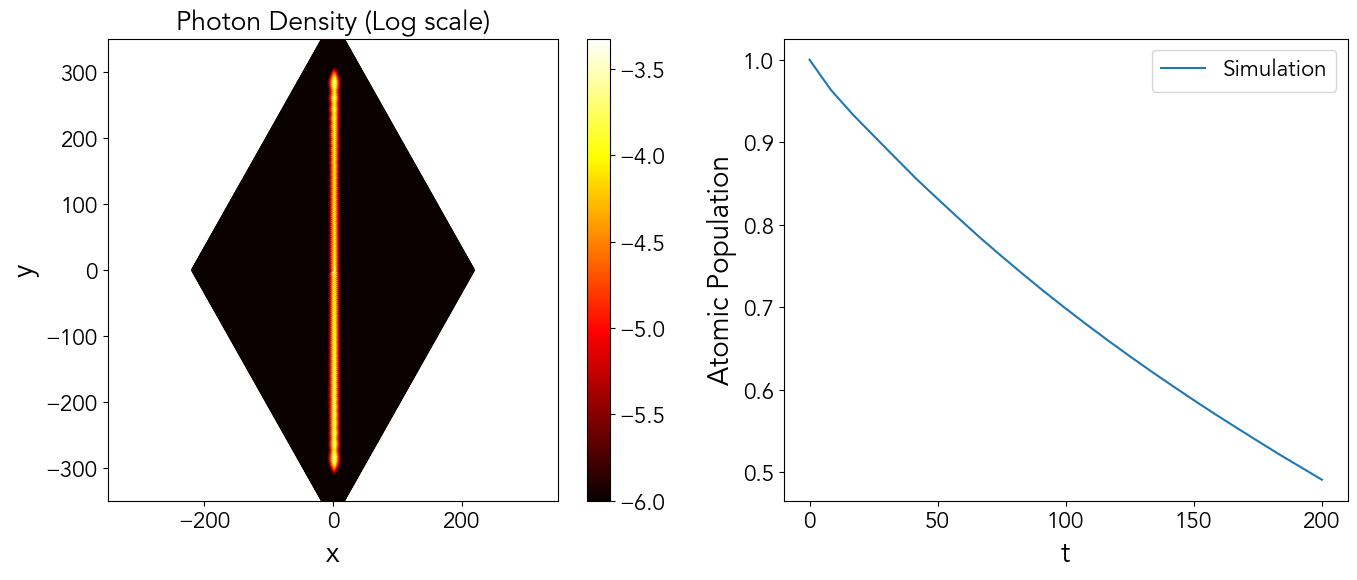

In [19]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe, label="Simulation")
axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\delta/2 = {DELTA/2}$")

axs[0].set_ylim(-350,350)
axs[0].set_xlim(-350, 350)

axs[1].legend()
plt.show()

fig.tight_layout()
fig.savefig(PATH + "emission_normal_atom.pdf", bbox_inches="tight")


In [63]:
vf = 3/2
beta = 2 * delta * lambda_0/vf
# decay_rate = (G ** 2 ) / (vf * lambda_0 * np.sqrt(np.pi)) * gamma(beta/2 + 1/2) / gamma(beta/2)

decay_rate =  (G ** 2) / (lambda_0 * vf * np.sqrt(np.pi)) * gamma(beta/2 + 1/2) / gamma(beta/2) * (3 * np.sqrt(3)/2)

Norm = np.sqrt(gamma(beta/2 + 1/2) * gamma(beta/2) / (lambda_0 * np.sqrt(np.pi)))

def alpha_y(t, y):
    const = -1j * 3 * G * Norm * np.sqrt(3 * NMAX/2)

    decay_rate = 0.1
    theta_plus = np.heaviside(vf * t + y, 0.5)
    theta_minus = np.heaviside(vf * t - y, 0.5)

    return np.exp(- decay_rate * y / (2 * vf)) * theta_plus + np.exp(decay_rate * y/ (2 * vf)) * theta_minus


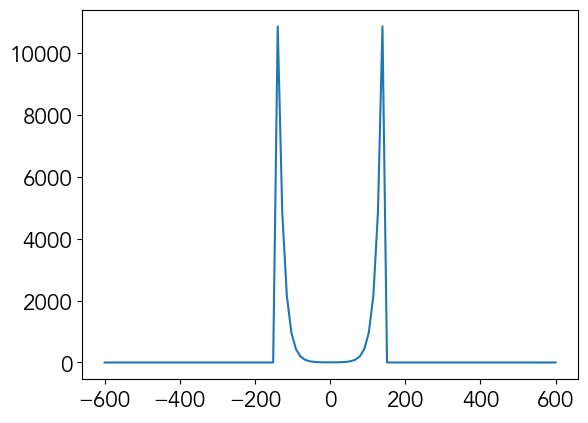

In [64]:
y = np.linspace(-600, 600, 100)
alpha = alpha_y(100, y)

alpha /= np.abs(alpha)

plt.plot(y, np.abs(alpha) ** 2)
# alpha = alpha_y(200, y)
# alpha /= np.abs(alpha)
# plt.plot(y, np.abs(alpha) ** 2)

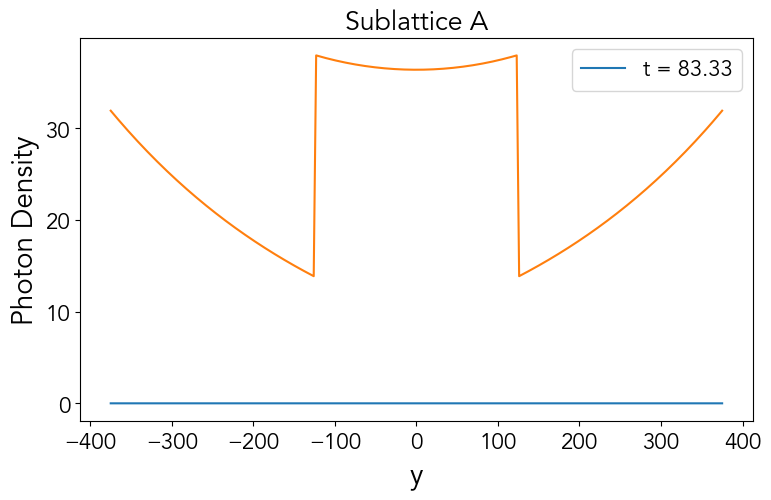

In [30]:
(y_a, c_a), (y_b, c_b) = slice_graphene(na, nb, Cna, Cnb)
fig, ax = plt.subplots(figsize=(8, 5))

t_indx = [10,12]

ax.plot(y_a, c_a[t_indx[0]], label=f"t = {t[t_indx[0]]:.2f}")
# ax.plot(y_a, c_a[t_indx[1]], label=f"t = {t[t_indx[1]]:.2f}")
alpha = alpha_y(t[t_indx[0]], y_a)
ax.plot(y_a, np.abs(alpha) ** 2)

ax.set_ylabel("Photon Density")

ax.set_xlabel("y")
ax.legend()
plt.tight_layout()

ax.set_title("Sublattice A")
# plt.xlim(-100, 100)
plt.show()

In [418]:
NMAX = 551
delta = 0.1
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.0
G = 0.07
atom_pos = (0,0)
NUM_POINTS = 25
TF = 400

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=0)

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

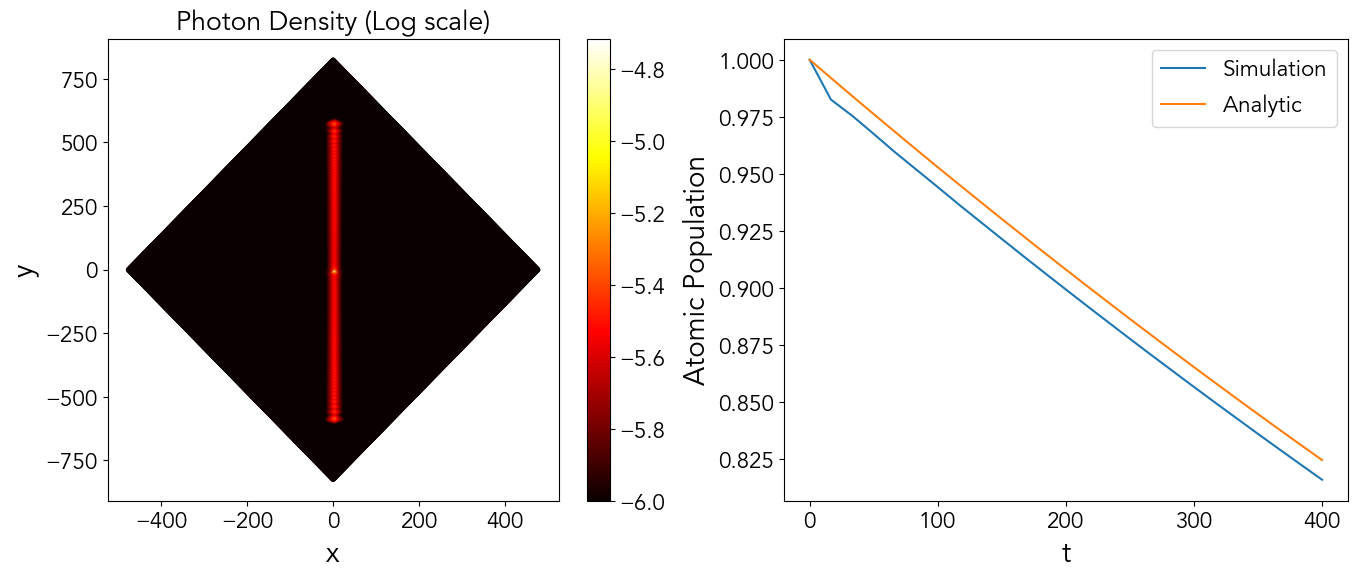

In [419]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe, label="Simulation")


vf = 3/2
beta = 2 * delta * lambda_0/vf
# decay_rate = (G ** 2 ) / (vf * lambda_0 * np.sqrt(np.pi)) * gamma(beta/2 + 1/2) / gamma(beta/2)

decay_rate =  (G ** 2) / (lambda_0 * vf * np.sqrt(np.pi)) * gamma(beta/2 + 1/2) / gamma(beta/2) * (3 * np.sqrt(3)/2)
pe_analyitic = np.exp(-t * decay_rate)
axs[1].plot(t, pe_analyitic, label="Analytic")

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

axs[1].legend()
plt.show()

fig.tight_layout()
fig.savefig(PATH + "emission_normal_atom.pdf", bbox_inches="tight")


a = 0.9911 ± 0.0001
b = 0.0005 ± 0.0000


/var/folders/q3/1z3g104x46n7562_5r_mvpl80000gn/T/ipykernel_5946/4162860962.py:5: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)


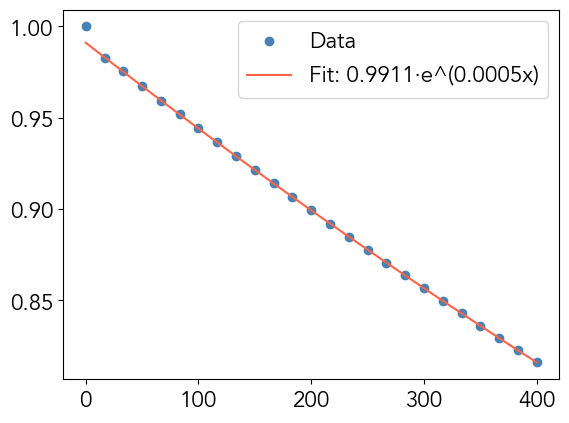

In [420]:
from scipy.optimize import curve_fit

# Define the model: y = a * e^(b*x)
def exponential(x, a, b):
    return a * np.exp(-b * x)

# Fit — p0 is the initial guess for [a, b]
params, covariance = curve_fit(exponential, t[1:], pe[1:], p0=[1, 0.5])
a, b = params

# Uncertainty (1 standard deviation)
std_devs = np.sqrt(np.diag(covariance))
print(f"a = {a:.4f} ± {std_devs[0]:.4f}")
print(f"b = {b:.4f} ± {std_devs[1]:.4f}")

# Plot
# x_fit = np.linspace(x.min(), x.max(), 200)
plt.scatter(t, pe, label="Data", color="steelblue")
plt.plot(t, exponential(t, a, b), label=f"Fit: {a:.4f}·e^({b:.4f}x)", color="tomato")
plt.legend()
plt.show()

In [421]:
decay_rate

np.float64(0.00048199556607828476)

In [422]:
b

np.float64(0.00048578641040102066)

In [332]:
b / decay_rate

np.float64(1.0078648945955662)

### Giant atom

In [79]:
NMAX = 251
DELTA = 0.1
J = 1.
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.0
G = 0.07
NUM_POINTS = 25
TF = 200

PHI = -np.pi/3
# PHI = np.pi/2

sys=System(
            lattice=Graphene(nmax=NMAX, J=J, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )

nx = range(- (NMAX // 2), NMAX // 2 + 1)
ny = range(- (NMAX // 2), NMAX // 2 + 1)

Nx, Ny = np.meshgrid(nx, ny)

na, nb = sys.lattice.n_real_pos

H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

0.4939726939854645


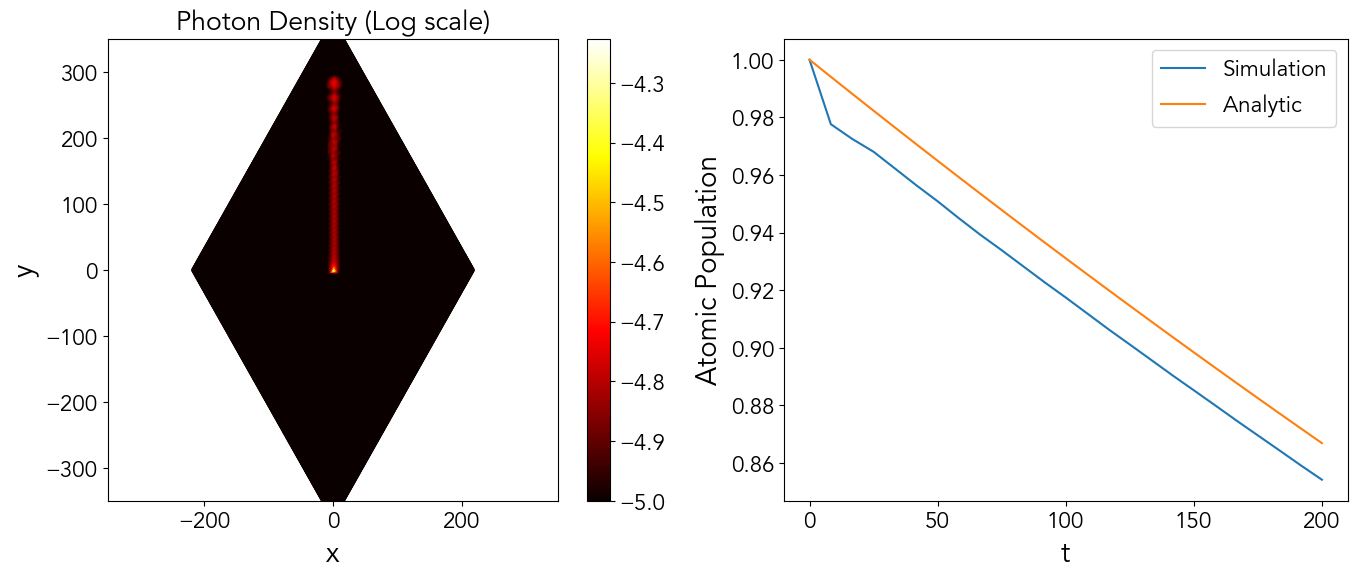

In [452]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)

vf = 3/2
betaO2 = DELTA * lambda_0 / vf
alpha = (np.cosh(np.sqrt(3)/(2 * lambda_0))) ** (- betaO2)

gamma_normal = (G**2) / (vf * lambda_0 * np.sqrt(np.pi)) * (3 * np.sqrt(3)/2) * gamma(betaO2 + 1/2) / gamma(betaO2)
gamma_giant = gamma_normal * (1 + alpha ** 2 + 2* alpha * np.cos(PHI) * np.cos(OMEGA_0/J - 2 * np.pi/3))

print(alpha * np.cos(PHI) * np.cos(3 * OMEGA_0/ (2 * vf)))

pe_analyitic = np.exp(-t * gamma_giant)

axs[1].plot(t, pe, label="Simulation")
axs[1].plot(t, pe_analyitic, label="Analytic")

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

axs[0].set_ylim(-350,350)
axs[0].set_xlim(-350, 350)

axs[1].legend()
plt.show()
fig.tight_layout()
fig.savefig(PATH + "emission_giant_atom2.pdf", bbox_inches="tight")


a = 0.9848 ± 0.0002
b = 0.0007 ± 0.0000


/var/folders/q3/1z3g104x46n7562_5r_mvpl80000gn/T/ipykernel_5946/4162860962.py:5: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)


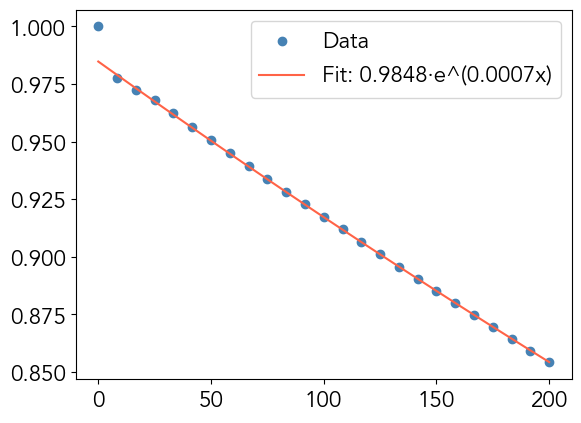

In [453]:
from scipy.optimize import curve_fit

# Define the model: y = a * e^(b*x)
def exponential(x, a, b):
    return a * np.exp(-b * x)

# Fit — p0 is the initial guess for [a, b]
params, covariance = curve_fit(exponential, t[1:], pe[1:], p0=[1, 0.5])
a, b = params

# Uncertainty (1 standard deviation)
std_devs = np.sqrt(np.diag(covariance))
print(f"a = {a:.4f} ± {std_devs[0]:.4f}")
print(f"b = {b:.4f} ± {std_devs[1]:.4f}")

# Plot
# x_fit = np.linspace(x.min(), x.max(), 200)
plt.scatter(t, pe, label="Data", color="steelblue")
plt.plot(t, exponential(t, a, b), label=f"Fit: {a:.4f}·e^({b:.4f}x)", color="tomato")
plt.legend()
plt.show()

In [454]:
b

np.float64(0.0007105448164135842)

In [455]:
gamma_giant

np.float64(0.0007143479853394132)

In [457]:
b/gamma_giant

np.float64(0.9946760276449552)

In [445]:
NMAX = 251
DELTA = 0.1
J = 1.
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.0
G = 0.07
NUM_POINTS = 25
TF = 200

# PHI = -np.pi/3
PHI = -np.pi/2
# NUM_POINTS = 50

sys=System(
            lattice=Graphene(nmax=NMAX, J=J, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )

nx = range(- (NMAX // 2), NMAX // 2 + 1)
ny = range(- (NMAX // 2), NMAX // 2 + 1)

Nx, Ny = np.meshgrid(nx, ny)

na, nb = sys.lattice.n_real_pos

H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

6.04942078555494e-17


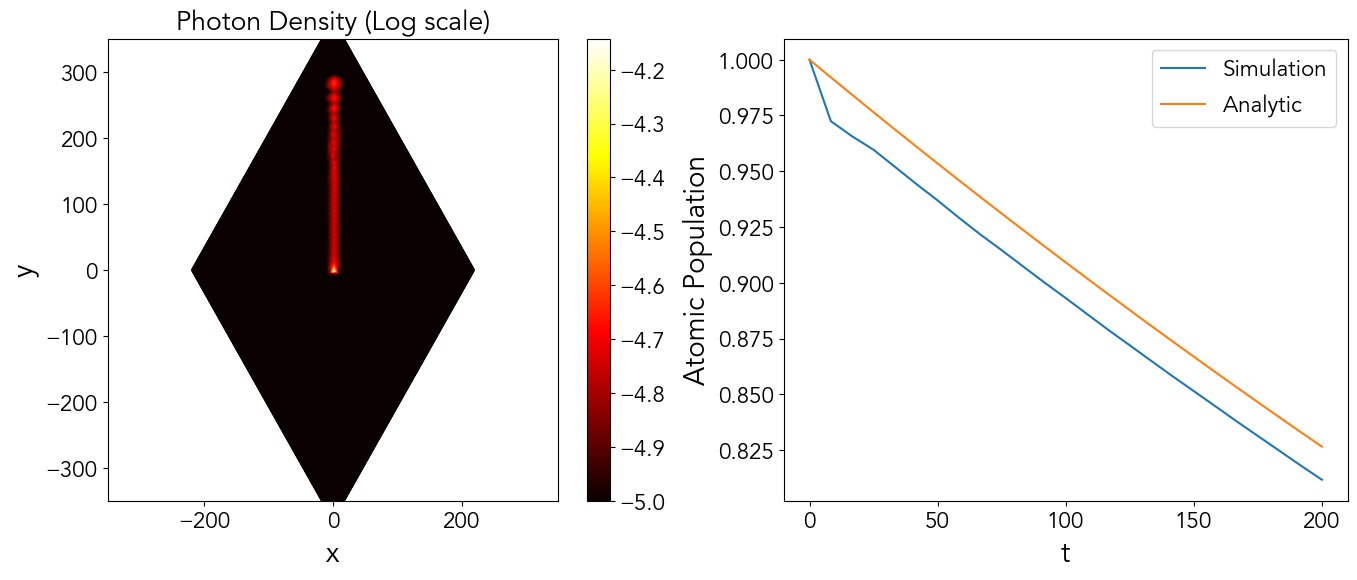

In [446]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)

vf = 3/2
betaO2 = DELTA * lambda_0 / vf
alpha = (np.cosh(np.sqrt(3)/(2 * lambda_0))) ** (- betaO2)

gamma_normal = (G**2) / (vf * lambda_0 * np.sqrt(np.pi)) * (3 * np.sqrt(3)/2) * gamma(betaO2 + 1/2) / gamma(betaO2)
gamma_giant = gamma_normal * (1 + alpha ** 2 + 2* alpha * np.cos(PHI) * np.cos(OMEGA_0/J - 2 * np.pi/3))

print(alpha * np.cos(PHI) * np.cos(3 * OMEGA_0/ (2 * vf)))

pe_analyitic = np.exp(-t * gamma_giant)

axs[1].plot(t, pe, label="Simulation")
axs[1].plot(t, pe_analyitic, label="Analytic")

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

axs[0].set_ylim(-350,350)
axs[0].set_xlim(-350, 350)

axs[1].legend()
plt.show()
fig.tight_layout()
fig.savefig(PATH + "emission_giant_atom1.pdf", bbox_inches="tight")


a = 0.9820 ± 0.0002
b = 0.0010 ± 0.0000


/var/folders/q3/1z3g104x46n7562_5r_mvpl80000gn/T/ipykernel_5946/4162860962.py:5: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)


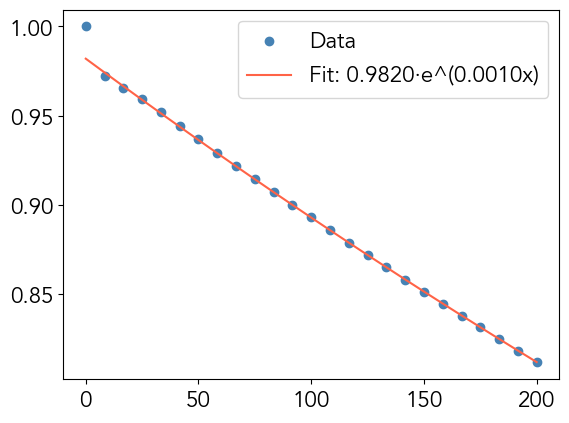

In [447]:
from scipy.optimize import curve_fit

# Define the model: y = a * e^(b*x)
def exponential(x, a, b):
    return a * np.exp(-b * x)

# Fit — p0 is the initial guess for [a, b]
params, covariance = curve_fit(exponential, t[1:], pe[1:], p0=[1, 0.5])
a, b = params

# Uncertainty (1 standard deviation)
std_devs = np.sqrt(np.diag(covariance))
print(f"a = {a:.4f} ± {std_devs[0]:.4f}")
print(f"b = {b:.4f} ± {std_devs[1]:.4f}")

# Plot
# x_fit = np.linspace(x.min(), x.max(), 200)
plt.scatter(t, pe, label="Data", color="steelblue")
plt.plot(t, exponential(t, a, b), label=f"Fit: {a:.4f}·e^({b:.4f}x)", color="tomato")
plt.legend()
plt.show()

In [448]:
b

np.float64(0.0009506376795123113)

In [449]:
gamma_giant

np.float64(0.0009524406336041525)

In [450]:
b/gamma_giant

np.float64(0.9981070168278955)

In [100]:
NMAX = 251
DELTA = 0.1
J = 1.
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.0
G = 0.07
NUM_POINTS = 25
TF = 400

# PHI = -np.pi/3
PHI = np.pi
# NUM_POINTS = 50

sys=System(
            lattice=Graphene(nmax=NMAX, J=J, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(2,2), phase=PHI),
            ]
    )

nx = range(- (NMAX // 2), NMAX // 2 + 1)
ny = range(- (NMAX // 2), NMAX // 2 + 1)

Nx, Ny = np.meshgrid(nx, ny)

na, nb = sys.lattice.n_real_pos

H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

-0.9879453879709288


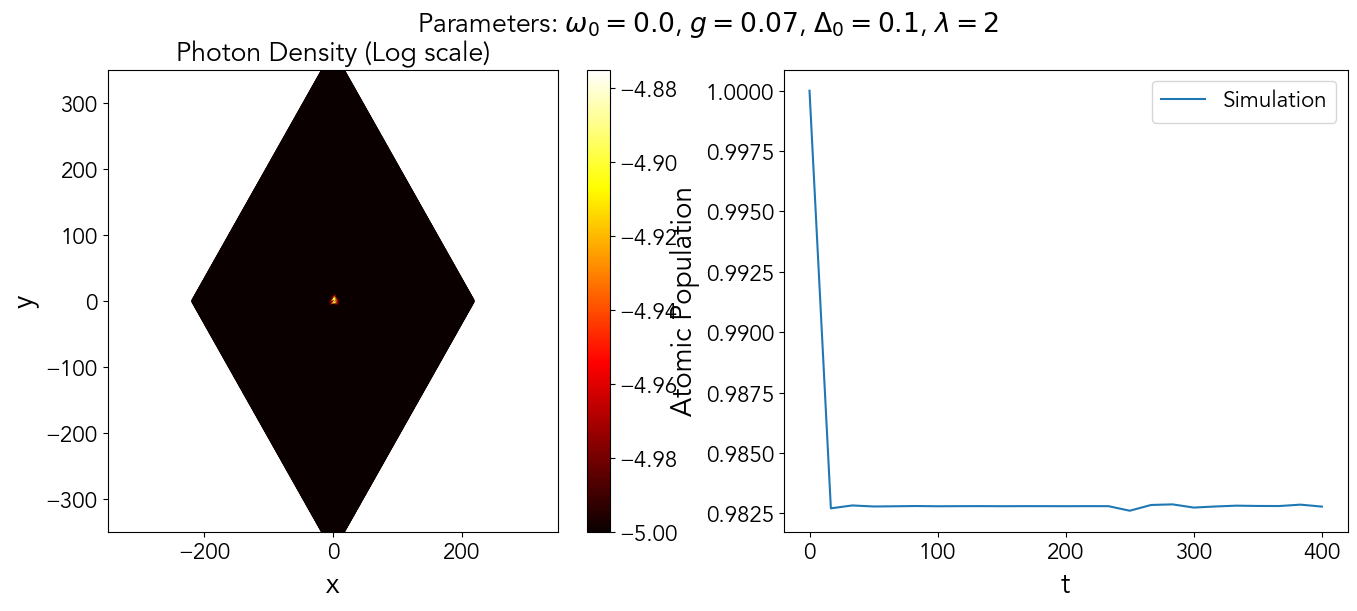

In [101]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)

vf = 3/2
betaO2 = DELTA * lambda_0 / vf
alpha = (np.cosh(np.sqrt(3)/(2 * lambda_0))) ** (- betaO2)

gamma_normal = (G**2) / (vf * lambda_0 * np.sqrt(np.pi)) * (3 * np.sqrt(3)/2) * gamma(betaO2 + 1/2) / gamma(betaO2)
gamma_giant = gamma_normal * (1 + alpha ** 2 + 2* alpha * np.cos(PHI) * np.cos(OMEGA_0/J - 2 * np.pi/3))

print(alpha * np.cos(PHI) * np.cos(3 * OMEGA_0/ (2 * vf)))

# pe_analyitic = np.exp(-t * gamma_giant)

axs[1].plot(t, pe, label="Simulation")
# axs[1].plot(t, pe_analyitic, label="Analytic")

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

axs[0].set_ylim(-350,350)
axs[0].set_xlim(-350, 350)

axs[1].legend()
plt.show()
fig.tight_layout()
# fig.savefig(PATH + "emission_giant_atom1.pdf", bbox_inches="tight")


In [ ]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)

vf = 3/2
betaO2 = DELTA * lambda_0 / vf
alpha = (np.cosh(np.sqrt(3)/(2 * lambda_0))) ** (- betaO2)

gamma_normal = (G**2) / (vf * lambda_0 * np.sqrt(np.pi)) * (3 * np.sqrt(3)/2) * gamma(betaO2 + 1/2) / gamma(betaO2)
gamma_giant = gamma_normal * (1 + alpha ** 2 + 2* alpha * np.cos(PHI) * np.cos(OMEGA_0/J - 2 * np.pi/3))

print(alpha * np.cos(PHI) * np.cos(3 * OMEGA_0/ (2 * vf)))

pe_analyitic = np.exp(-t * gamma_giant)

axs[1].plot(t, pe, label="Simulation")
axs[1].plot(t, pe_analyitic, label="Analytic")

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

axs[0].set_ylim(-350,350)
axs[0].set_xlim(-350, 350)

axs[1].legend()
plt.show()
fig.tight_layout()
fig.savefig(PATH + "emission_giant_atom1.pdf", bbox_inches="tight")


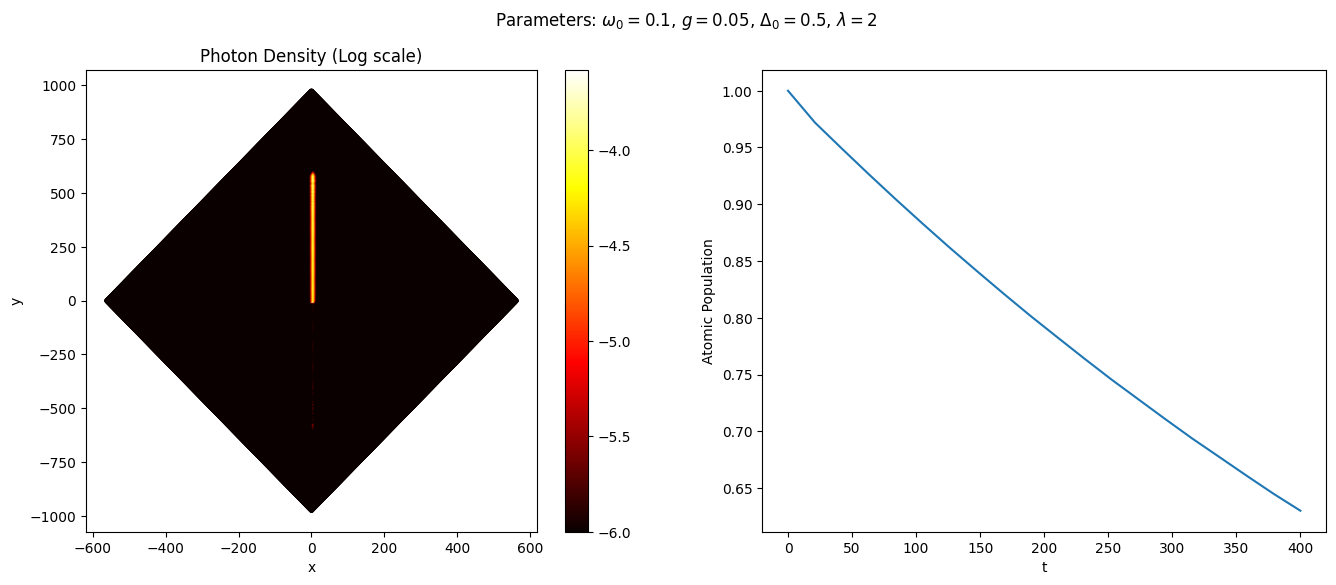

In [ ]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


## Emission in a angle

In [215]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 150

THETA = 30 # in degrees
PHI = -np.pi/3
TF = 200
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=THETA),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

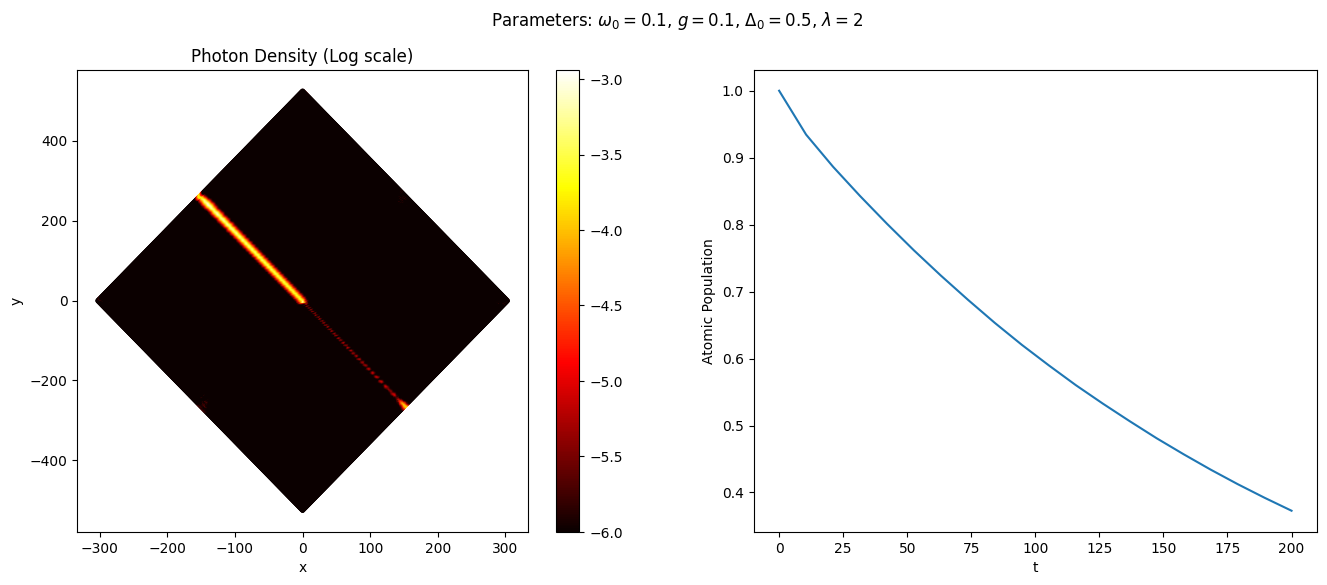

In [ ]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


In [315]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25

THETA = 90 # in degrees
PHI = np.pi/3
TF = 180
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=THETA),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

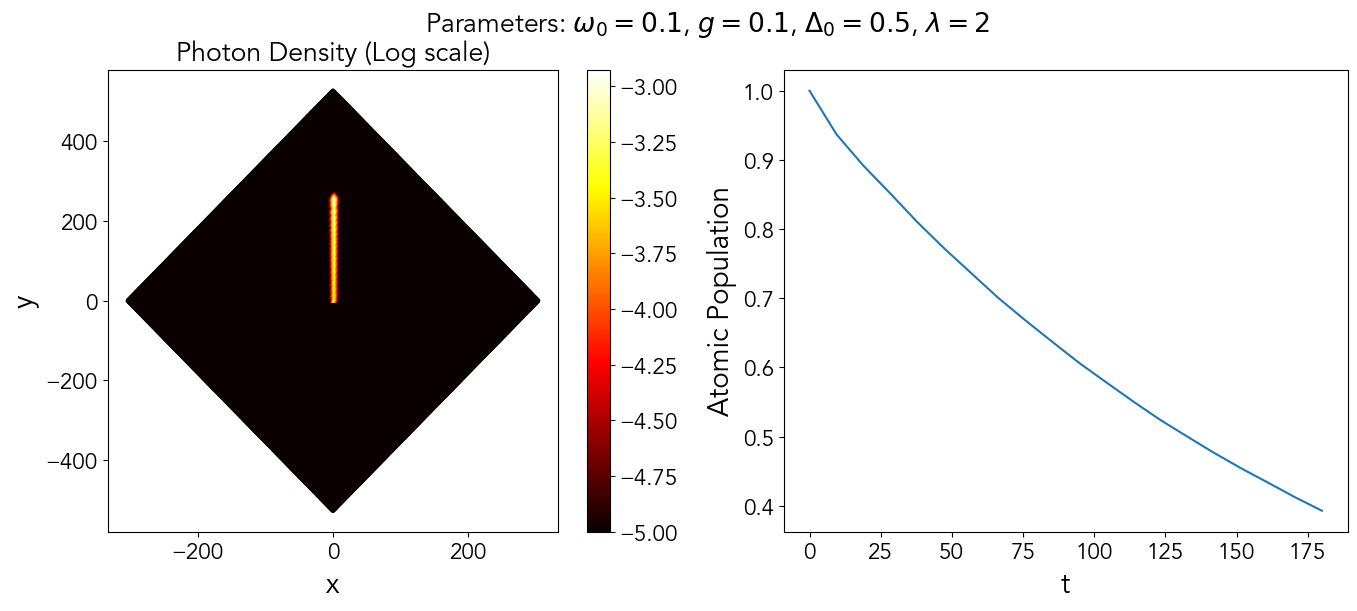

In [316]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


In [313]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25

THETA = 45 # in degrees
PHI = -np.pi/3
TF = 180
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y", domain_wall_angle=THETA),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

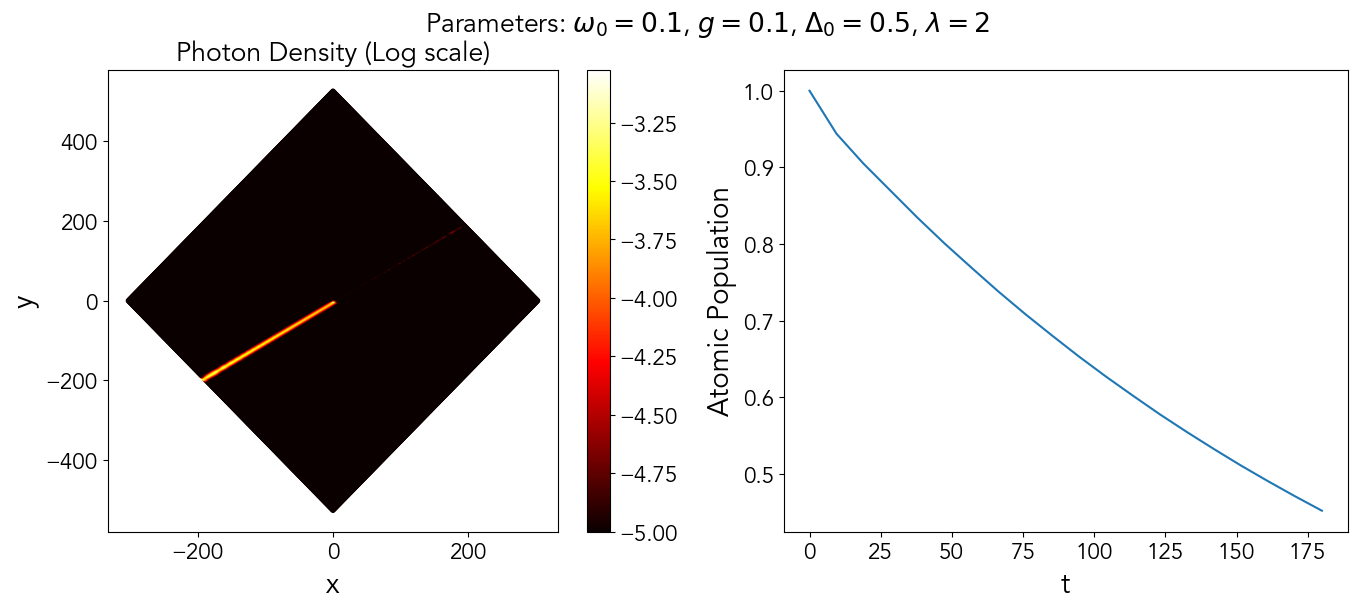

In [314]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


## Changing the gap size

In [319]:
NMAX = 351
DELTA = 0.1
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25

THETA = 90 # in degrees
PHI = np.pi/3
TF = 180
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y", domain_wall_angle=THETA),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

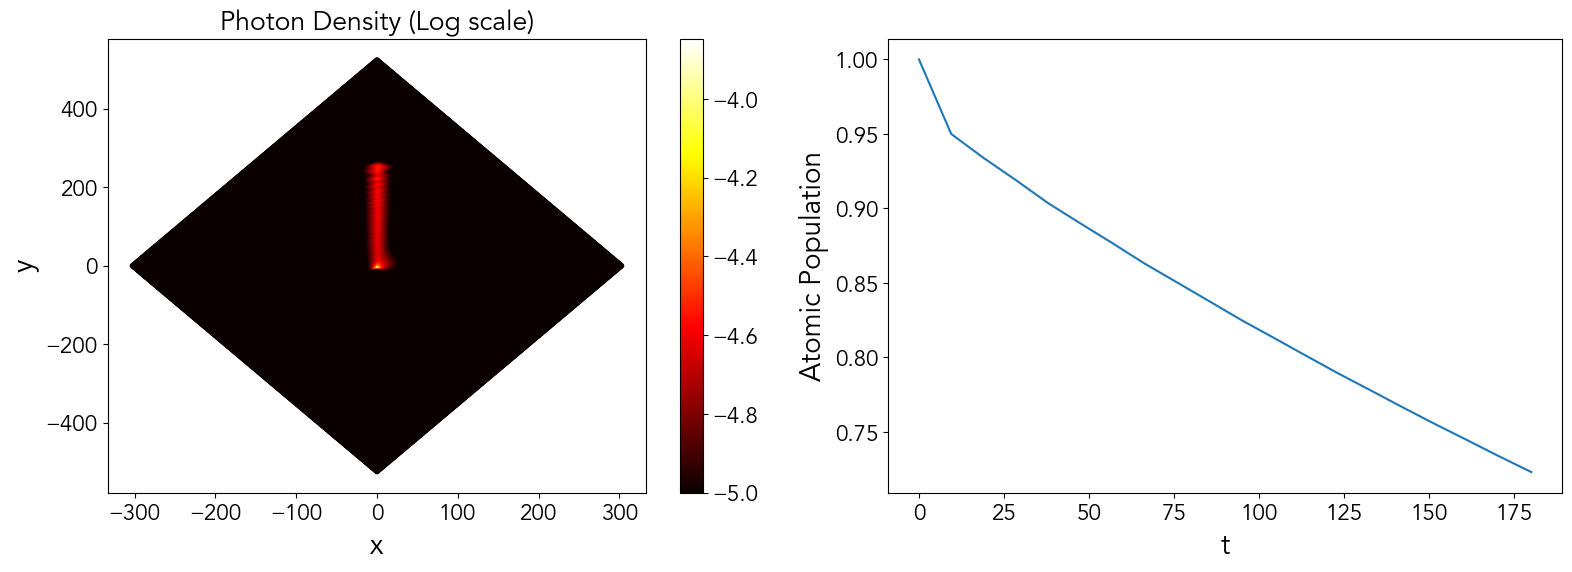

In [321]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)
fig.tight_layout()
plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")
fig.savefig(PATH + f"emission_giant_atom_delta={DELTA}.pdf", bbox_inches="tight")


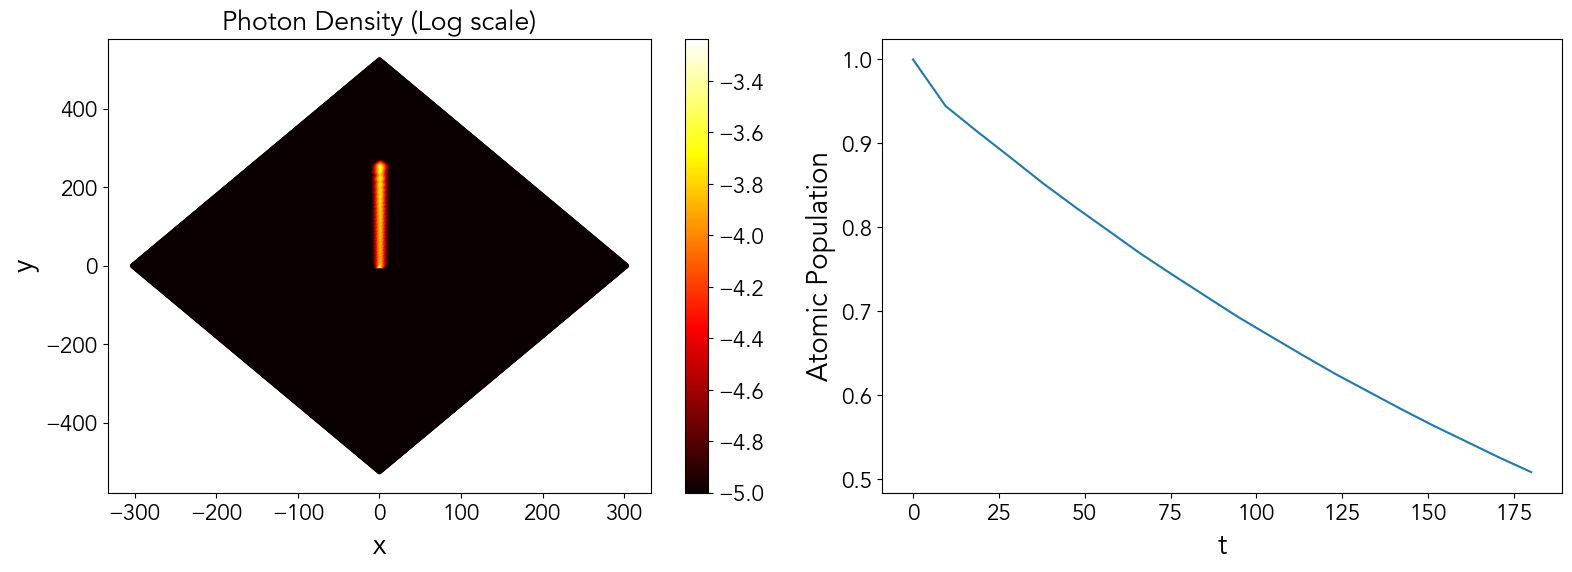

In [322]:
NMAX = 351
DELTA = 0.3
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25

THETA = 90 # in degrees
PHI = np.pi/3
TF = 180
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y", domain_wall_angle=THETA),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)
fig.tight_layout()
plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")
fig.savefig(PATH + f"emission_giant_atom_delta={DELTA}.pdf", bbox_inches="tight")


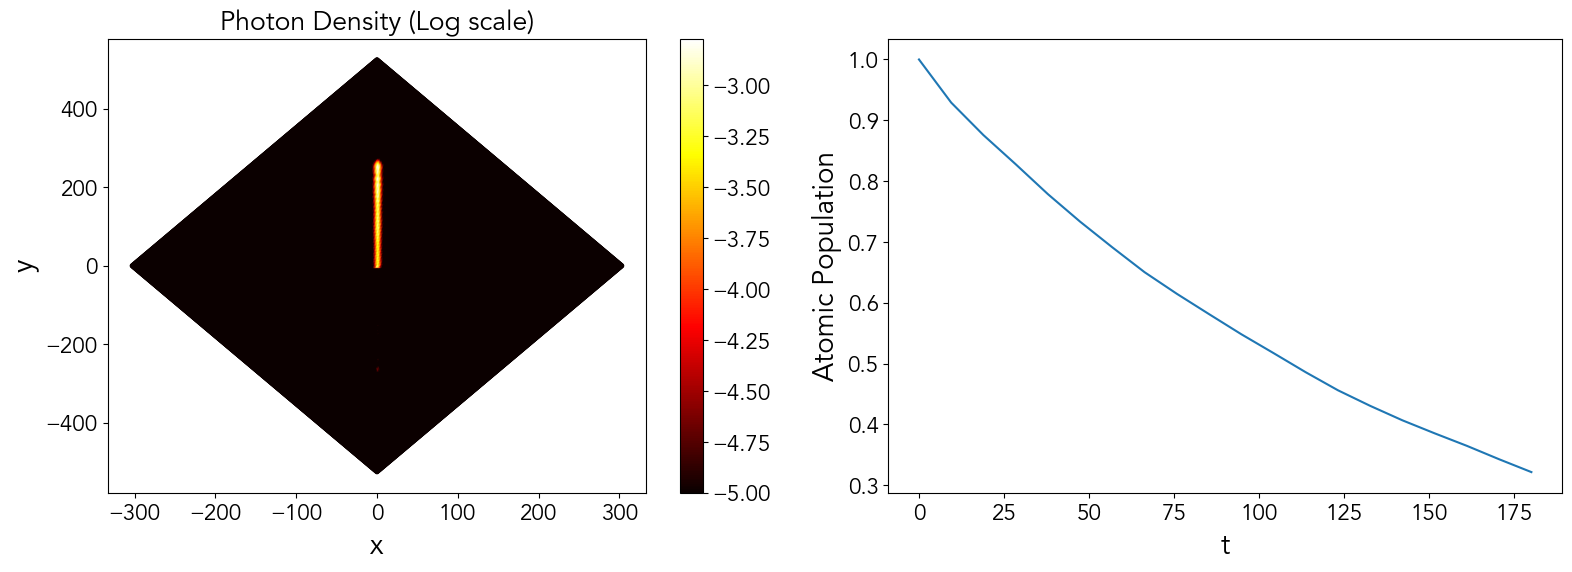

In [323]:
NMAX = 351
DELTA = 0.7
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25

THETA = 90 # in degrees
PHI = np.pi/3
TF = 180
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y", domain_wall_angle=THETA),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)
fig.tight_layout()
plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")
fig.savefig(PATH + f"emission_giant_atom_delta={DELTA}.pdf", bbox_inches="tight")


In [ ]:
NMAX = 351
DELTAS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 200

PHI = -np.pi/3
TF = 200
NUM_POINTS = 20

Cnas = []
Cnbs = []
pes  = []


for DELTA in DELTAS:
  sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


  H = add_atom_to_hamiltonian(sys)
  dim = H.shape[0]

  t = np.linspace(0, TF, NUM_POINTS)

  psi = np.zeros(dim, dtype=np.cdouble)
  psi[-1] = 1. # Atom starts on excited state
  psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


  psi_atom = psi[:, -1]
  psi_latt = psi[:,:-1]

  psi_a = psi_latt[:,:sys.lattice.la]
  psi_b = psi_latt[:,sys.lattice.la:]

  psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
  psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

  Cna = np.abs(psi_a) ** 2
  Cnb = np.abs(psi_b) ** 2
  pe = np.abs(psi_atom) ** 2

  Cnas.append(Cna)
  Cnbs.append(Cnb)
  pes.append(pe)

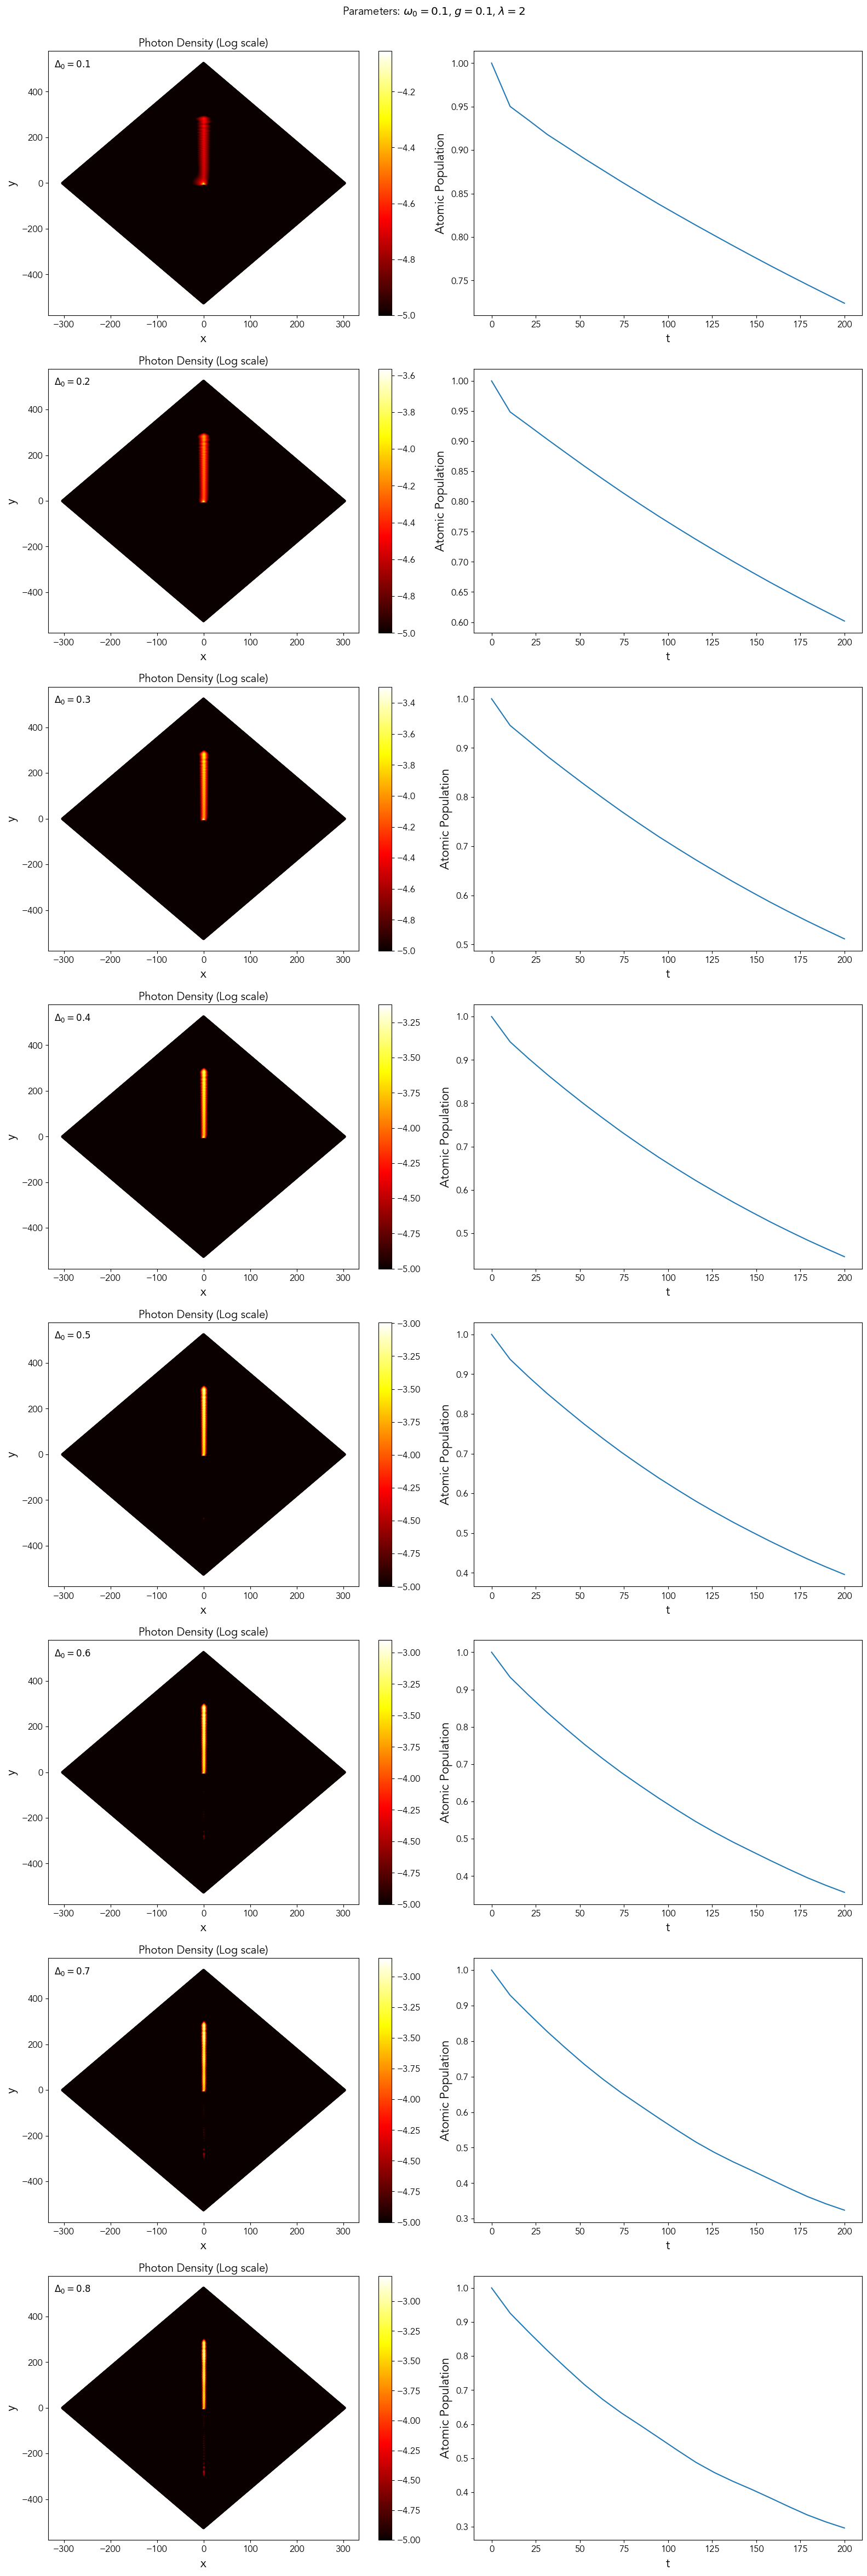

In [261]:
FIG_SIZE = (16, 6 * len(DELTAS)) 
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

fig, axs = plt.subplots(nrows= len(DELTAS), ncols=2, figsize=FIG_SIZE)

na, nb = sys.lattice.n_real_pos
for i, (Cna, Cnb, pe) in enumerate(zip(Cnas, Cnbs, pes)):
  im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[i, 0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

  fig.colorbar(im, ax=axs[i, 0])

  if FILL:
      axs[i, 0].set_facecolor("black")

  axs[i,0].set_title("Photon Density (Log scale)")
  axs[i,0].set_xlabel('x')
  axs[i,0].set_ylabel('y')

  a1 = lattice.a1
  a2 = lattice.a2

  # draw_basis_vectors(axs[0], [a1, a2])
  # annotate_electric_field_text(axs[0], sys)


  axs[i,1].plot(t, pe)

  axs[i,1].set_xlabel("t")
  axs[i,1].set_ylabel("Atomic Population")

  axs[i, 0].text(
      0.02, 0.97,
      f"$\\Delta_0 = {DELTAS[i]}$",
      transform=axs[i, 0].transAxes,
      color="black",
      fontsize=12,
      va="top", ha="left"
  )
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\lambda = {lambda_0}$")

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.show()
fig.savefig("comparision_many_deltas.png", dpi=300)


## Rotation of the emission

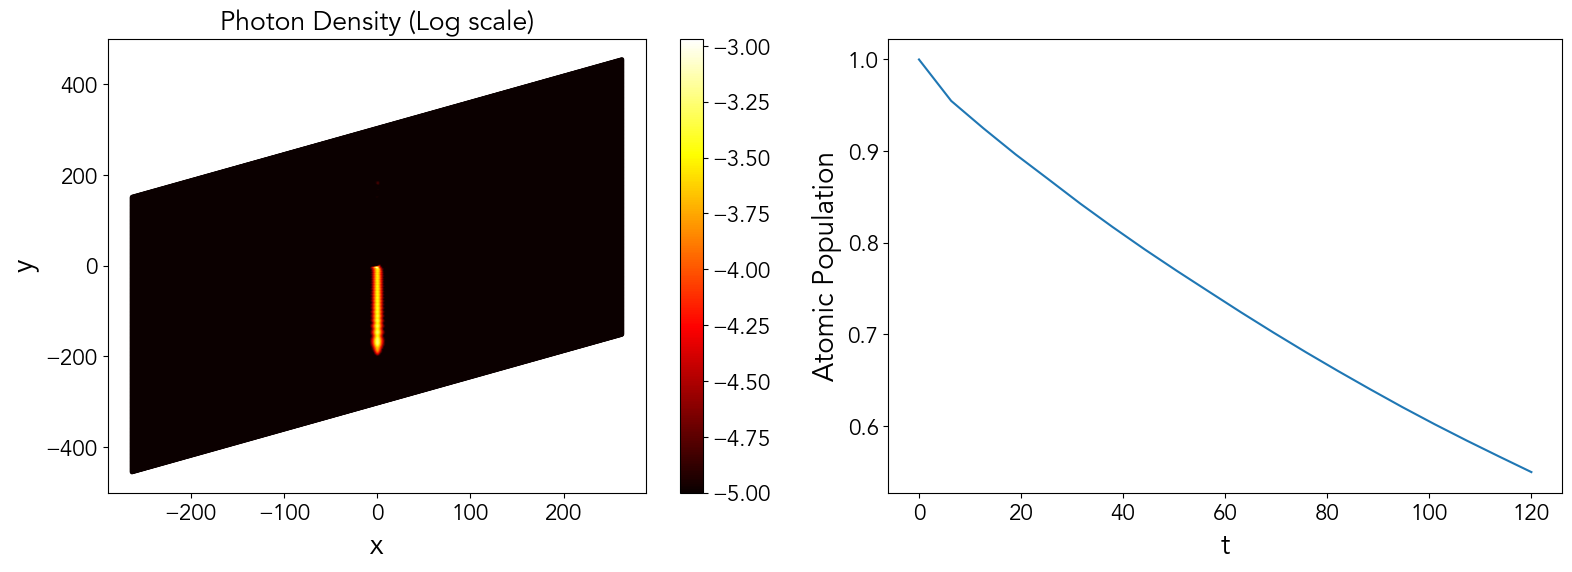

In [152]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25

THETA = 0 # in degrees
PHI = np.pi/3
TF = 120
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y", domain_wall_angle=THETA),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)
fig.tight_layout()
plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")
fig.savefig(PATH + f"rotation_emission_giant_atom_theta={THETA}.pdf", bbox_inches="tight")


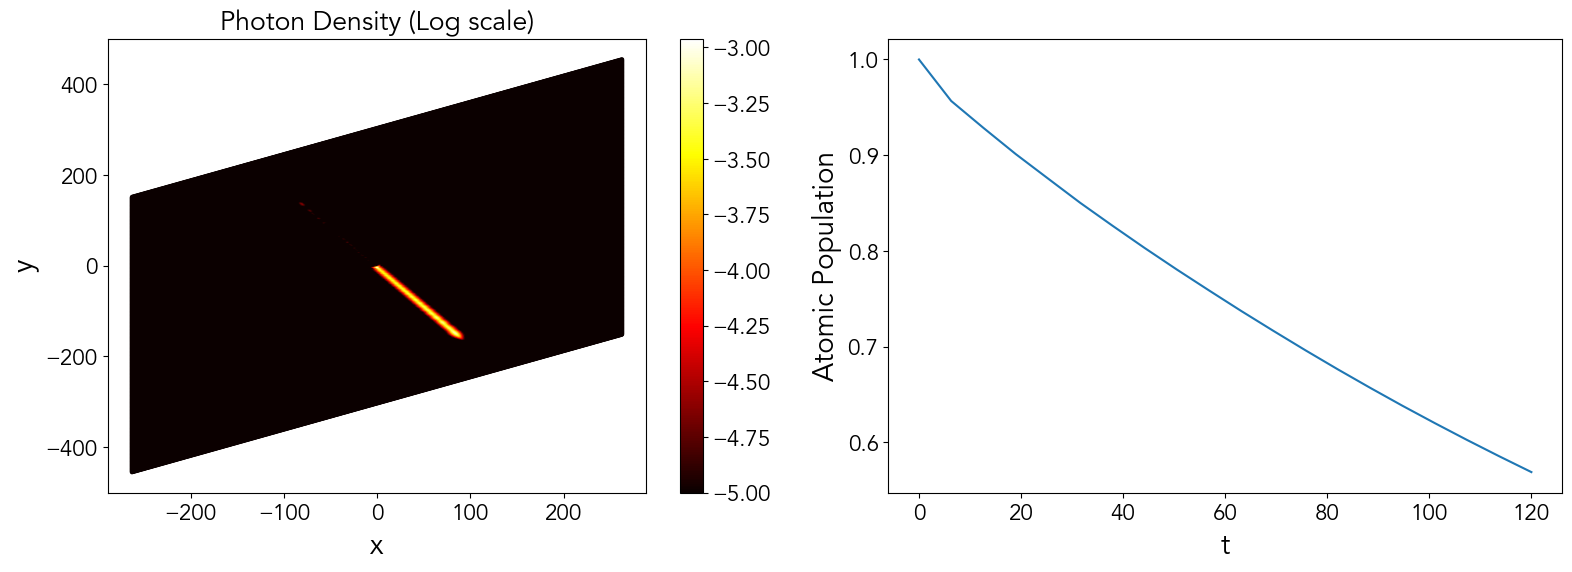

In [153]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25

THETA = 30 # in degrees
PHI = np.pi/3
TF = 120
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y", domain_wall_angle=THETA),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)
fig.tight_layout()
plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")
fig.savefig(PATH + f"rotation_emission_giant_atom_theta={THETA}.pdf", bbox_inches="tight")


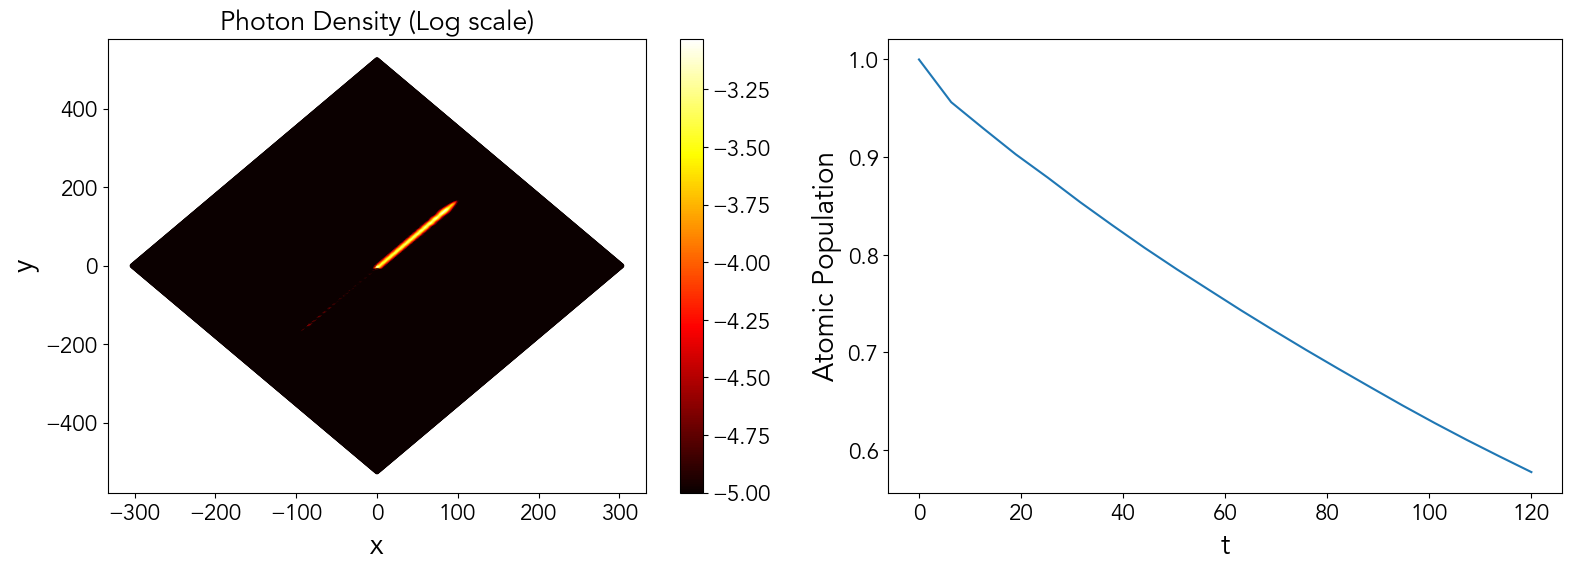

: 

In [ ]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25

THETA = 60 # in degrees
PHI = np.pi/3
TF = 120
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y", domain_wall_angle=THETA),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)
fig.tight_layout()
plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")
fig.savefig(PATH + f"rotation_emission_giant_atom_theta={THETA}.pdf", bbox_inches="tight")


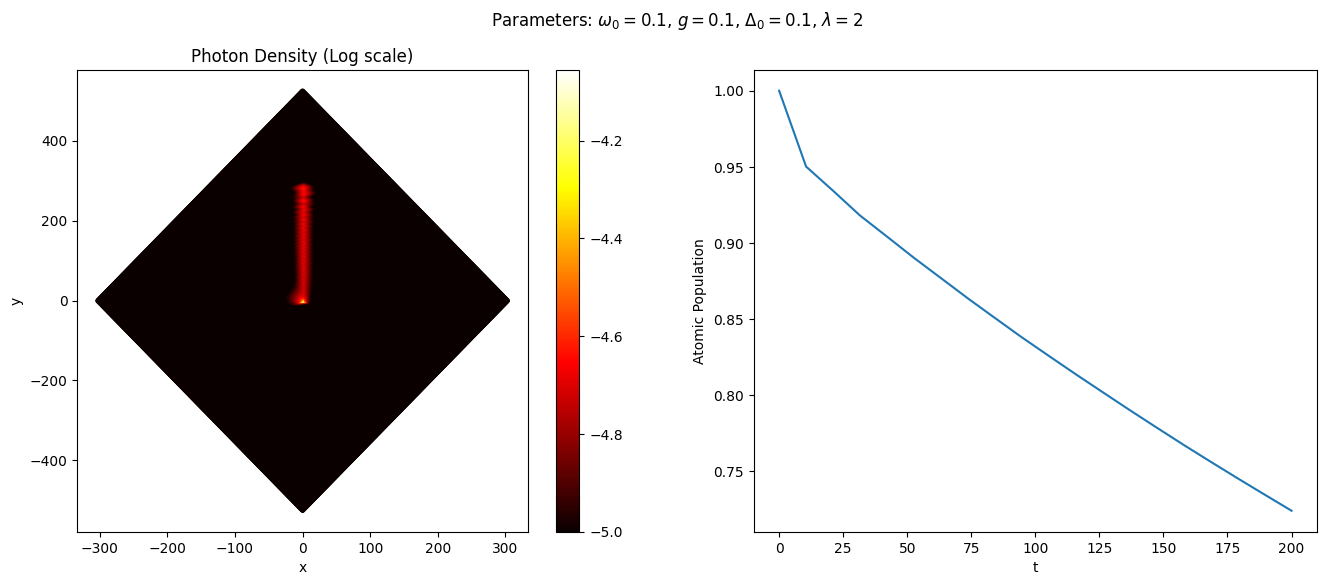

In [246]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


---

In [202]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 200

PHI = -np.pi/3
TF = 200
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

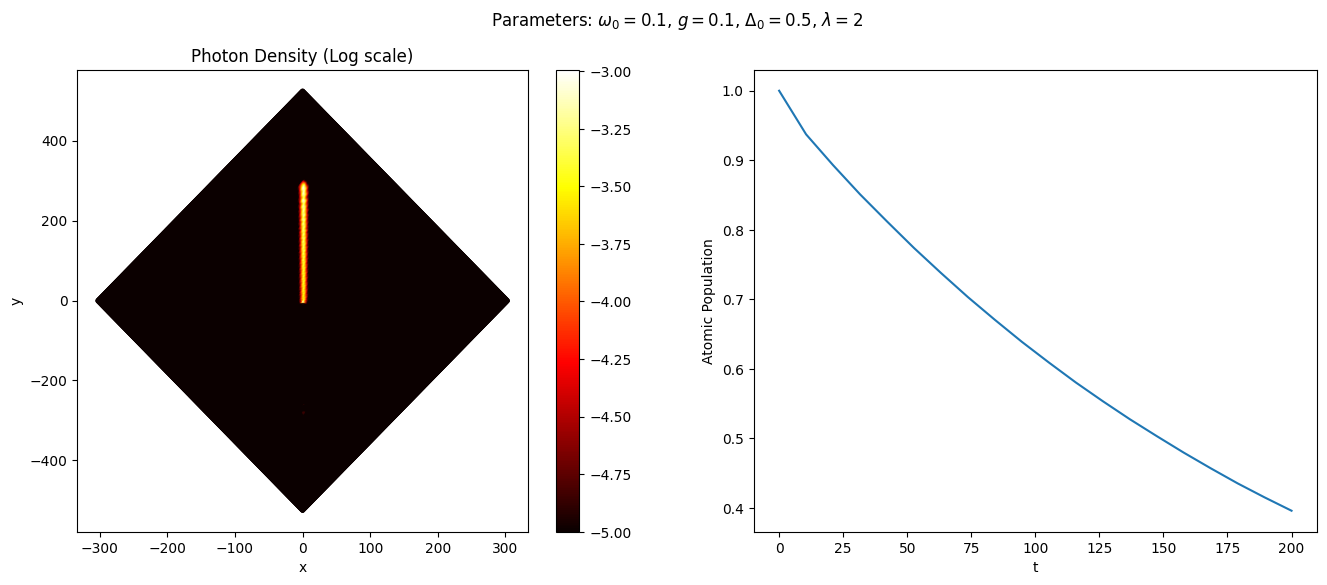

In [204]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


In [205]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 200

PHI = np.pi/3
TF = 200
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

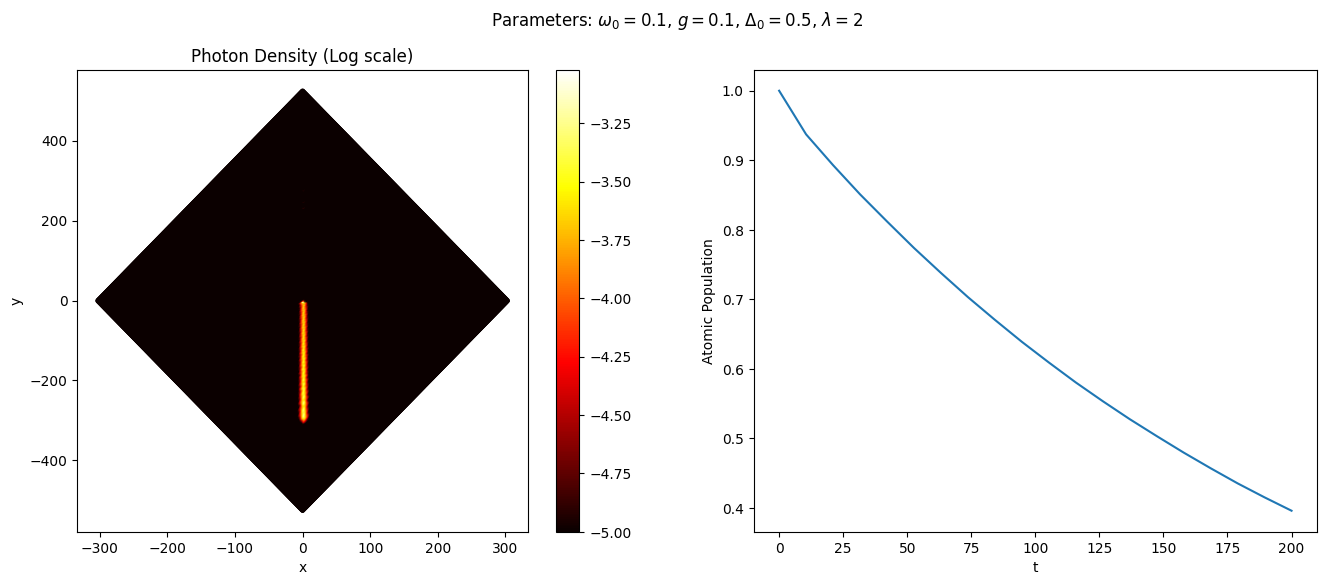

In [206]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


In [208]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 200

PHI = np.pi/3
TF = 100
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_along="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

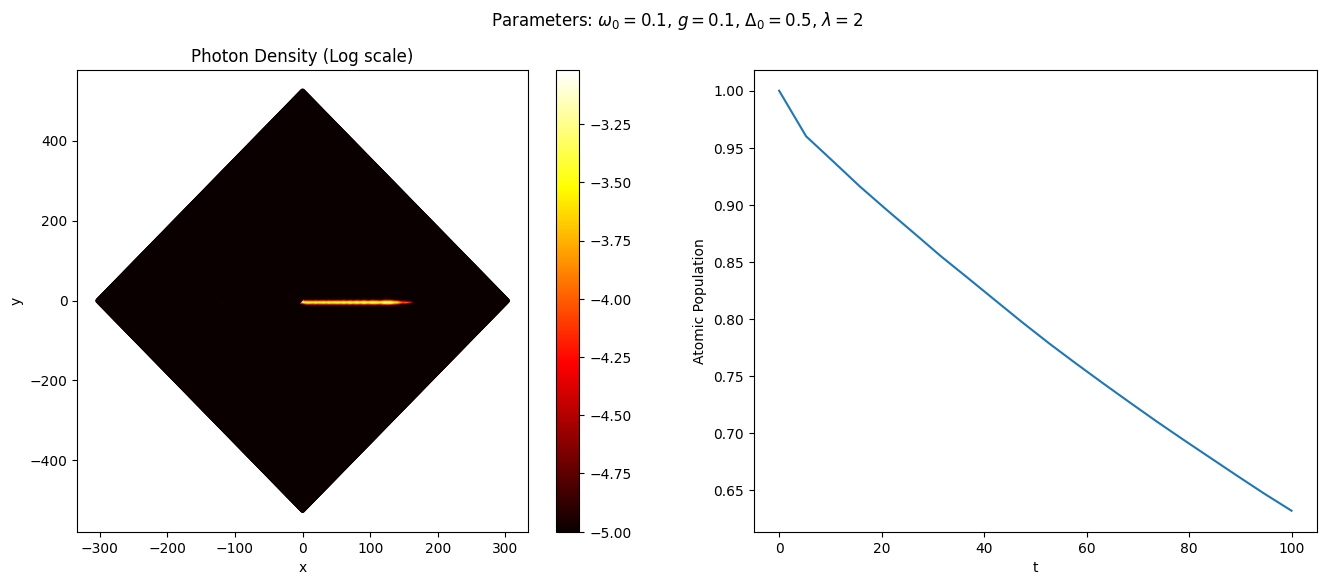

In [209]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


In [210]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 200

PHI = -np.pi/3
TF = 100
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_along="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

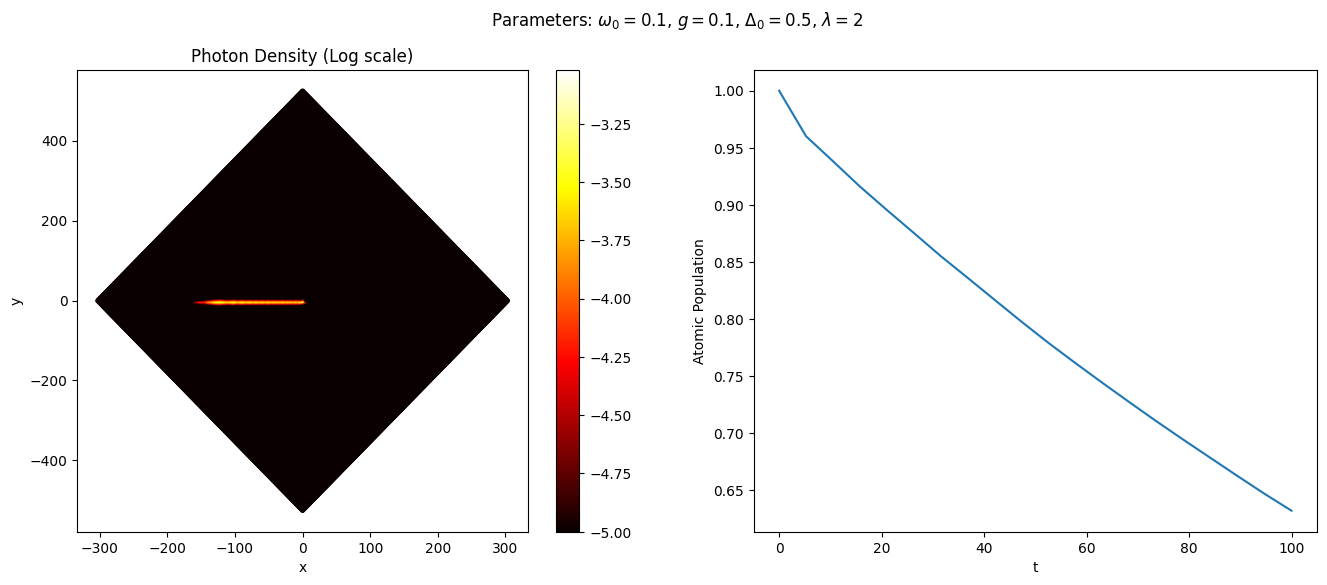

In [211]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


Text(0, 0.5, 'Eigenvalues')

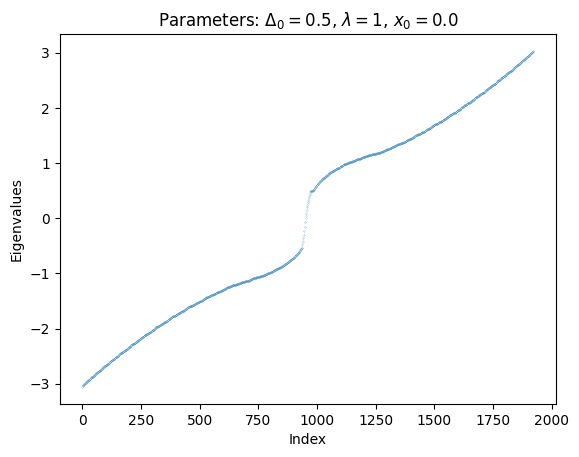

In [57]:
nmax = 31
delta = 0.5
lambda_0 = 1
x0 = 0.

lattice = Graphene(nmax=nmax, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y")

eigval, eigvec = np.linalg.eigh(lattice.hamiltonian.todense())

plt.plot(eigval, "o", markersize=0.1)

plt.title(f"Parameters: $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$, $x_0 = {x0}$")
plt.xlabel("Index")
plt.ylabel("Eigenvalues")

Text(0, 0.5, 'Eigenvalues')

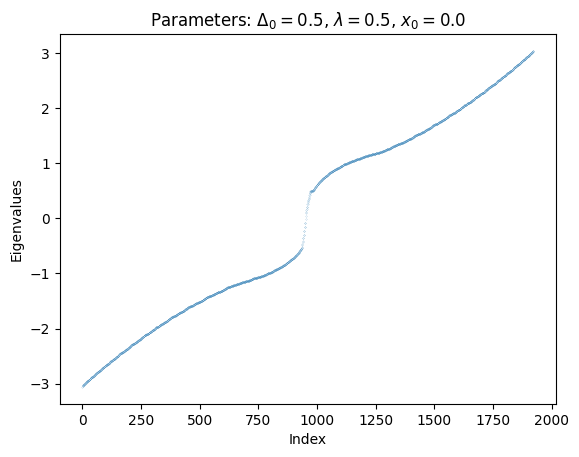

In [58]:
nmax = 31
delta = 0.5
lambda_0 = 0.5
x0 = 0.

lattice = Graphene(nmax=nmax, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y")

eigval, eigvec = np.linalg.eigh(lattice.hamiltonian.todense())

plt.plot(eigval, "o", markersize=0.1)

plt.title(f"Parameters: $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$, $x_0 = {x0}$")
plt.xlabel("Index")
plt.ylabel("Eigenvalues")

Text(0, 0.5, 'Eigenvalues')

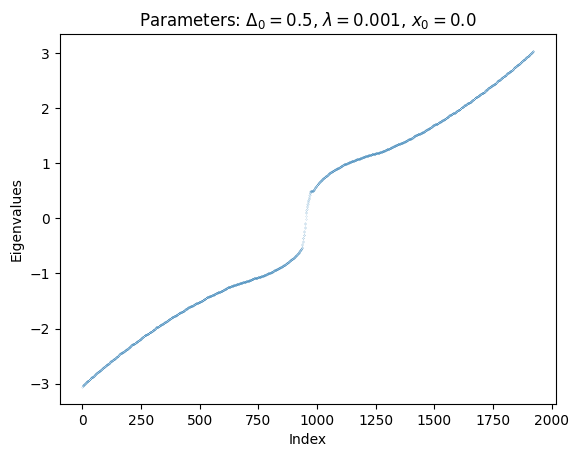

In [60]:
nmax = 31
delta = 0.5
lambda_0 = 0.001
x0 = 0.

lattice = Graphene(nmax=nmax, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y")

eigval, eigvec = np.linalg.eigh(lattice.hamiltonian.todense())

plt.plot(eigval, "o", markersize=0.1)

plt.title(f"Parameters: $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$, $x_0 = {x0}$")
plt.xlabel("Index")
plt.ylabel("Eigenvalues")

In [ ]:
a = np.array([1,2,3])
b = np.array

np.vstack()

In [5]:
def generate_rotation_matrix(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

## Testing the boundary conditions

In [6]:
nmax = 4
N = nmax ** 2
connections = {
    n: [
        n + nmax if n + nmax < N else None, 
        n + nmax - 1 if n + nmax < N else None, 
        n + 1 if n + 1 < N else None, 
        n - 1 if n - 1 >=0 else None, 
        n - nmax + 1 if n - nmax >= 0 else None, 
        n - nmax if n - nmax >= 0 else None
        ] for n in range(N)
}

In [7]:
def check_connections(m, N, connections):
    c = np.arange(N)[connections]
    site_row = m // nmax
    same_rows = (c // nmax) == site_row
    next_rows = np.abs((c // nmax) - site_row) == 1
    distance_row = np.abs(c - m) == 1

    return c[(same_rows & distance_row) | next_rows]


In [8]:
nmax = 4
N = nmax ** 2
connections = {
    n: check_connections(
        m=n,
        N=N,
        connections=np.array([
                n + nmax, 
                n + nmax - 1, 
                n + 1, 
                n - 1 , 
                n - nmax + 1 , 
                n - nmax 
                ]) % N
            ) for n in range(N)
}

In [9]:
M = np.zeros((N,N))
for key, value in connections.items():
    M[key, value] = 1

In [10]:
# M

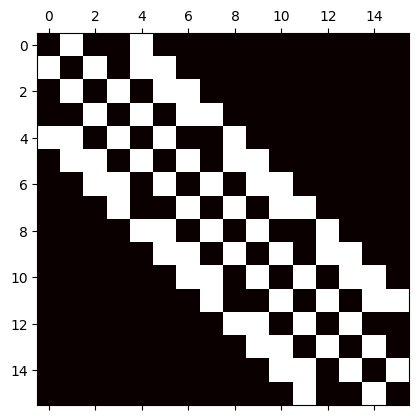

In [11]:
im = plt.matshow(M, cmap="hot")
# plt.colorbar(im)

In [12]:
check_connections(m=5, N=N, connections=connections[5])

array([9, 8, 6, 4, 2, 1])

In [13]:
nmax = 4
N = nmax ** 2
connections_pbc = {
    n: [
        (n + nmax) % N, 
        (n + nmax - 1) % N, 
        (n + 1) % N, 
        (n - 1) % N, 
        (n - nmax + 1) % N, 
        (n - nmax) % N
        ] for n in range(N)
}
M_PBC = np.zeros((N, N))

for key, value in connections_pbc.items():
    M_PBC[key, value] = 1

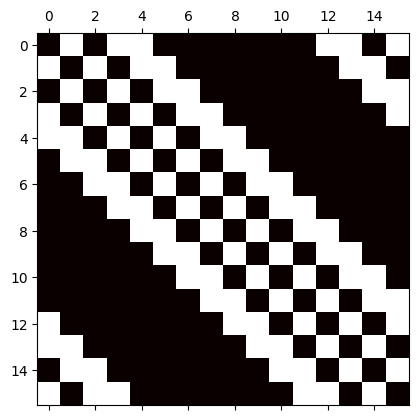

In [14]:
plt.matshow(M_PBC, cmap="hot")

In [15]:
m = 5
c = np.arange(N)[connections[m]]

site_row = m // nmax
same_rows = (c // nmax) == site_row
next_rows = np.abs((c // nmax) - site_row) == 1
distance_row = np.abs(c - m) == 1

c[(same_rows & distance_row) | next_rows]

array([9, 8, 6, 4, 2, 1])

## PBC y

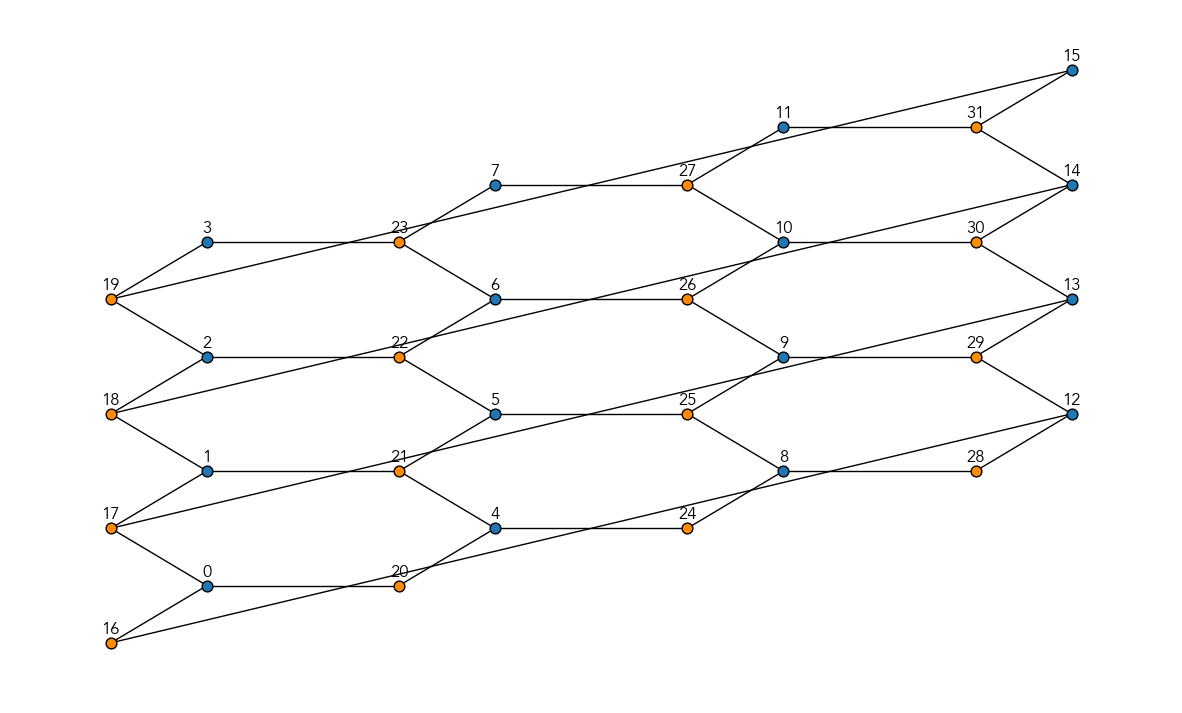

In [150]:
# print(connections[0])
lattice=Graphene(nmax=4, J_prime=0, pbc="x")
fig, _ = lattice.plot(True)

In [17]:
G = lattice.graph

In [18]:
G.edges(11)

EdgeDataView([(11, 27), (11, 31)])

## PBC x

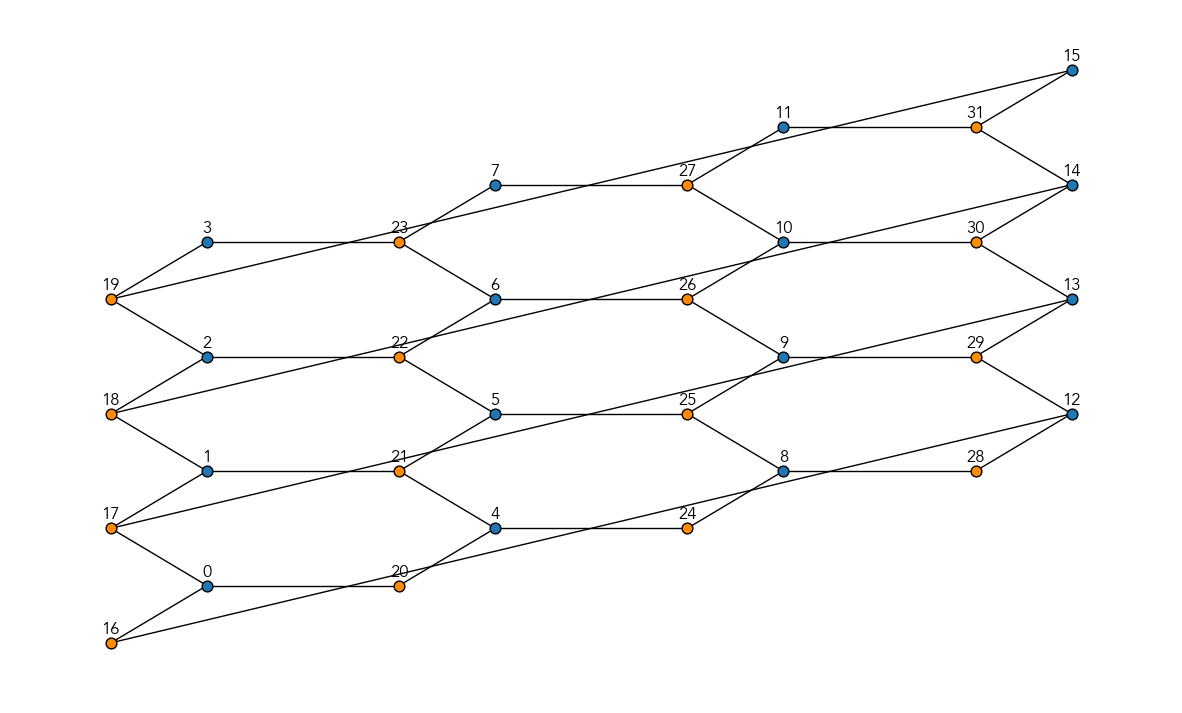

In [155]:
lattice=Graphene(nmax=4, pbc="x")
fig, _ = lattice.plot(True)

array([[[1, 2],
        [3, 4]]])

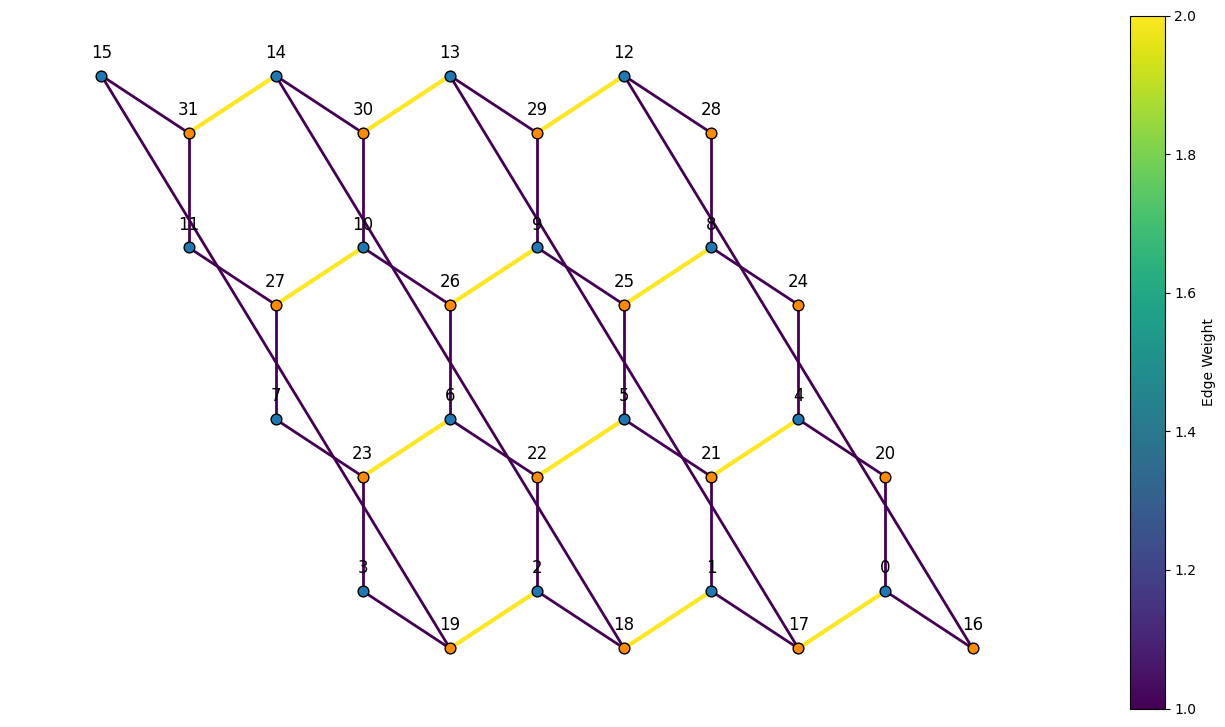

In [20]:
# print(connections[0])
lattice=Graphene(nmax=4, pbc="y", anisotropy_J=2)
fig, _ = lattice.plot(True, theta_rot=np.pi/3, color_by_weight=True)

# fig.savefig("graphene.svg")

In [31]:
lattice=Graphene(nmax=4, J_prime=-1, pbc=None)


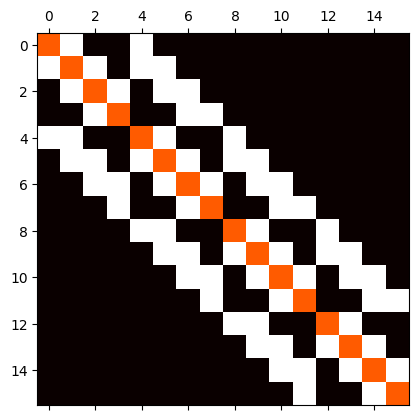

In [ ]:
# Non PBC
nmax = 4

def build_diag(ki):
    k = np.full(nmax ** 2 - ki, 1.)
    
    if ki == 1:
      k[nmax-1::nmax] = 0
      return k
    
    if ki == nmax - 1:
       k[::nmax] = 0
       return k
    
    if ki == (2 * nmax - 1):
       k[:] = 0
       k[::nmax] = 1.
       return k

    return k


energy = np.full(nmax ** 2, 0.5)

ks = [1, nmax - 1, nmax]
k = [build_diag(ki) for ki in ks]
offsets = ks + [-ki for ki in ks]

M = diags([energy] + k * 2, offsets=[0] + offsets)

plt.matshow(M.todense(), cmap="hot")

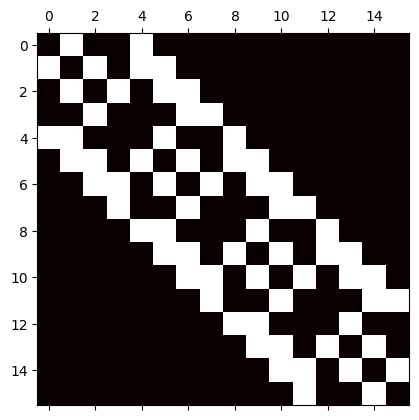

In [281]:
# Non PBC

nmax = 4


k1 = np.full(nmax ** 2 - 1, 1.)
k1[nmax-1::nmax] = 0 # k = 1 


k3 = np.full(nmax ** 2 - (nmax - 1), 1.)
k3[::nmax] = 0 # k = 3 


k4 = np.full(nmax ** 2 - nmax, 1.)

M = diags([k1, k3, k4] * 2, offsets=[1, nmax - 1, nmax, -1, -(nmax-1), - nmax])

plt.matshow(M.todense(), cmap="hot")

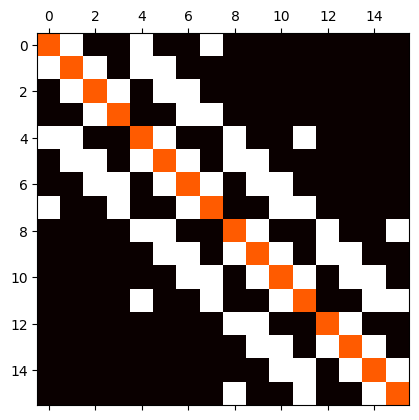

In [ ]:
# PBC X

energy = np.full(nmax ** 2, 0.5)

ks = [1, nmax - 1, nmax, 2 * nmax - 1]
k = [build_diag(ki) for ki in ks]
offsets = ks + [-ki for ki in ks]

M = diags([energy] + k * 2, offsets=[0] + offsets)

plt.matshow(M.todense(), cmap="hot")

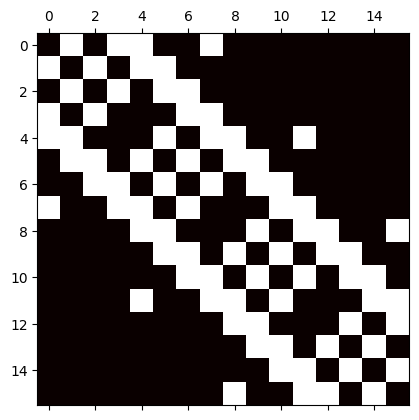

In [ ]:
# PBC X

nmax = 4

k1 = np.full(nmax ** 2 - 1, 1.)
k1[nmax-1::nmax] = 0 # k = 1 


k3 = np.full(nmax ** 2 - (nmax - 1), 1.)
k4 = np.full(nmax ** 2 - nmax, 1.)

k7 = np.zeros(nmax ** 2 - (2 * nmax - 1))
k7[::nmax] = 1


M = diags([k1, k3, k4, k7] * 2, offsets=[1, (nmax - 1), nmax, (2 * nmax - 1), -1, -(nmax - 1), -nmax, -(2 * nmax - 1)])

plt.matshow(M.todense(), cmap="hot")

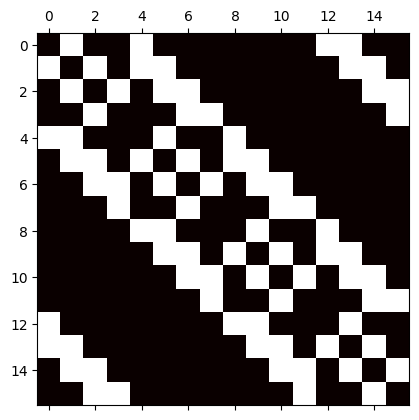

In [59]:
# PBC Y

energy = np.full(nmax ** 2, 0.)

ks = [1, nmax - 1, nmax, nmax * (nmax - 1), nmax * (nmax - 1) + 1]
k = [build_diag(ki) for ki in ks]
offsets = ks + [-ki for ki in ks]

M = diags([energy] + k * 2, offsets=[0] + offsets)

plt.matshow(M.todense(), cmap="hot")

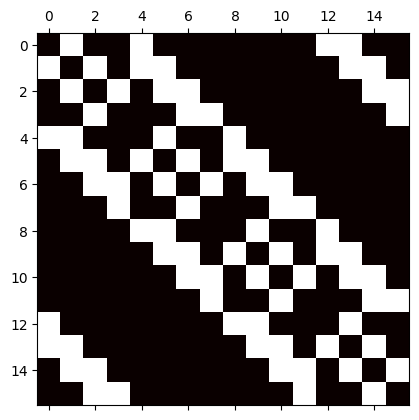

In [ ]:

PBC = "y"
nmax = 4

ks = [1, nmax - 1, nmax]
kextra = []

if PBC == "y":
    kextra = [nmax * (nmax - 1), nmax * (nmax - 1) + 1]

if PBC == "x":
    kextra = [2 * nmax - 1]

if PBC == "xy":
    kextra = [nmax * (nmax - 1), nmax * (nmax - 1) + 1, 2 * nmax - 1]

ks += kextra
ksm = [-k for k in ks]

K = [np.full(nmax ** 2 - k, 1.)for k in ks]

K[0][nmax-1::nmax] = 0
K[1][::nmax] = 0
if PBC == ("x" or "xy"):
    K[1] = 1.
    K[-1] = np.zeros(nmax ** 2 - (2 * nmax - 1))
    K[-1][::nmax] = 1.
    
K = K * 2
ks = ks + ksm

M = diags(K, offsets=ks)

plt.matshow(M.todense(), cmap="hot")

In [291]:
nmax ** 2 - nmax

12

In [ ]:
k11 = np.full()